# Đồ án cuối kỳ: Phân loại và Phân cụm Dữ liệu Airline Passenger Satisfaction
#Danh sác thành viên nhóm M3gan
| STT | Họ và tên |
| :--- | :--- |
| 1 | **Phan Cao Hiển (X)** |
| 2 | **Bùi Quốc Đạt** |
| 3 | **Nguyễn Lê Đăng Khôi** |
| 4 | **Huỳnh Khánh Nhân** |
## 1. Giới thiệu
Dự án này là đồ án cuối kỳ môn học sử dụng bộ dữ liệu [Airline Passenger Satisfaction](https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction), mục tiêu của dự án là xây dựng ***Mô hình Phân cụm (Clustering)***, giúp phân nhóm khách hàng và đánh giá chất lượng phân cụm dựa trên nhãn thực tế (ground truth).


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Chuẩn bị dữ liệu và tiền xử lý

In [ ]:
from google.colab import files
import pandas as pd
import io

# Bước 1: Tải tệp lên từ máy tính (Chọn tệp .csv)
uploaded = files.upload()

# Bước 2: Kiểm tra và đọc tệp CSV
for fn in uploaded.keys():
  if fn.endswith('.csv'):
    print(f'Đang xử lý tệp: "{fn}"')
    data = pd.read_csv(io.BytesIO(uploaded[fn]))
    display(data.head())
  else:
    print(f'Cảnh báo: Tệp "{fn}" không phải là CSV. Vui lòng tải lên tệp .csv')


Saving train.csv to train.csv
Đang xử lý tệp: "train.csv"


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


###2.1. Hợp nhất và Xáo trộn dữ liệu
Kết hợp dữ liệu từ hai nguồn tập tin khác nhau và xáo trộn thứ tự các bản ghi nhằm tạo ra một bộ dữ liệu tổng hợp khách quan, loại bỏ tính thiên lệch hệ thống trước khi huấn luyện mô hình, bao gồm các bước sau:

In [ ]:
data_train=pd.read_csv('/content/train.csv')
data_train

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,103899,94171,Female,disloyal Customer,23,Business travel,Eco,192,2,1,...,2,3,1,4,2,3,2,3,0.0,neutral or dissatisfied
103900,103900,73097,Male,Loyal Customer,49,Business travel,Business,2347,4,4,...,5,5,5,5,5,5,4,0,0.0,satisfied
103901,103901,68825,Male,disloyal Customer,30,Business travel,Business,1995,1,1,...,4,3,2,4,5,5,4,7,14.0,neutral or dissatisfied
103902,103902,54173,Female,disloyal Customer,22,Business travel,Eco,1000,1,1,...,1,4,5,1,5,4,1,0,0.0,neutral or dissatisfied


In [ ]:
# Bước 1: Tải tệp lên từ máy tính (Chọn tệp .csv)
uploaded1 = files.upload()

# Bước 2: Kiểm tra và đọc tệp CSV
for fn in uploaded1.keys():
  if fn.endswith('.csv'):
    print(f'Đang xử lý tệp: "{fn}"')
    data1 = pd.read_csv(io.BytesIO(uploaded1[fn]))
    display(data.head())
  else:
    print(f'Cảnh báo: Tệp "{fn}" không phải là CSV. Vui lòng tải lên tệp .csv')

data1

Saving test.csv to test.csv
Đang xử lý tệp: "test.csv"


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,25971,78463,Male,disloyal Customer,34,Business travel,Business,526,3,3,...,4,3,2,4,4,5,4,0,0.0,neutral or dissatisfied
25972,25972,71167,Male,Loyal Customer,23,Business travel,Business,646,4,4,...,4,4,5,5,5,5,4,0,0.0,satisfied
25973,25973,37675,Female,Loyal Customer,17,Personal Travel,Eco,828,2,5,...,2,4,3,4,5,4,2,0,0.0,neutral or dissatisfied
25974,25974,90086,Male,Loyal Customer,14,Business travel,Business,1127,3,3,...,4,3,2,5,4,5,4,0,0.0,satisfied


In [ ]:
data_test=pd.read_csv('/content/test.csv')
data_test

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,25971,78463,Male,disloyal Customer,34,Business travel,Business,526,3,3,...,4,3,2,4,4,5,4,0,0.0,neutral or dissatisfied
25972,25972,71167,Male,Loyal Customer,23,Business travel,Business,646,4,4,...,4,4,5,5,5,5,4,0,0.0,satisfied
25973,25973,37675,Female,Loyal Customer,17,Personal Travel,Eco,828,2,5,...,2,4,3,4,5,4,2,0,0.0,neutral or dissatisfied
25974,25974,90086,Male,Loyal Customer,14,Business travel,Business,1127,3,3,...,4,3,2,5,4,5,4,0,0.0,satisfied


In [ ]:
df=pd.concat([data_train,data_test])
df

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,25971,78463,Male,disloyal Customer,34,Business travel,Business,526,3,3,...,4,3,2,4,4,5,4,0,0.0,neutral or dissatisfied
25972,25972,71167,Male,Loyal Customer,23,Business travel,Business,646,4,4,...,4,4,5,5,5,5,4,0,0.0,satisfied
25973,25973,37675,Female,Loyal Customer,17,Personal Travel,Eco,828,2,5,...,2,4,3,4,5,4,2,0,0.0,neutral or dissatisfied
25974,25974,90086,Male,Loyal Customer,14,Business travel,Business,1127,3,3,...,4,3,2,5,4,5,4,0,0.0,satisfied


In [ ]:
df=df.sample(frac=1)
df

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
42087,42087,90103,Female,disloyal Customer,27,Business travel,Eco,957,1,1,...,2,4,4,3,1,4,2,1,0.0,neutral or dissatisfied
25572,25572,81510,Female,Loyal Customer,53,Personal Travel,Eco Plus,528,3,3,...,1,1,3,1,3,1,3,0,0.0,neutral or dissatisfied
25858,25858,17299,Female,Loyal Customer,36,Business travel,Business,403,5,5,...,4,4,4,4,5,4,1,0,0.0,satisfied
30719,30719,15870,Female,Loyal Customer,47,Business travel,Business,2098,3,3,...,4,4,4,4,3,4,5,5,0.0,satisfied
65563,65563,45367,Female,Loyal Customer,27,Personal Travel,Eco,188,2,4,...,3,3,3,4,3,4,3,0,0.0,neutral or dissatisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27064,27064,26451,Female,Loyal Customer,37,Business travel,Eco,925,4,4,...,4,2,2,2,4,5,4,0,0.0,satisfied
22684,22684,96769,Female,Loyal Customer,52,Business travel,Business,3249,3,3,...,5,5,5,5,3,5,5,0,0.0,satisfied
61802,61802,49545,Male,Loyal Customer,32,Business travel,Eco,308,5,1,...,5,2,1,5,1,3,5,0,0.0,satisfied
94983,94983,106344,Female,Loyal Customer,60,Business travel,Business,2067,5,5,...,5,5,5,5,4,5,5,0,0.0,satisfied


##2.2. Làm sạch và Mã hóa
 Thực hiện loại bỏ các cột dữ liệu không mang giá trị dự báo và chuyển đổi các biến định tính (văn bản) sang dạng số để mạng Nơ-ron có thể thực hiện các phép toán trên dữ liệu đầu vào, bao gồm các bước sau:

In [ ]:
df.dtypes

,0
Unnamed: 0,int64
id,int64
Gender,object
Customer Type,object
Age,int64
Type of Travel,object
Class,object
Flight Distance,int64
Inflight wifi service,int64
Departure/Arrival time convenient,int64


In [ ]:
df['Customer Type'].unique()

array(['disloyal Customer', 'Loyal Customer'], dtype=object)

In [ ]:
df['Customer Type']=df['Customer Type'].replace('Loyal Customer',1)
df['Customer Type']=df['Customer Type'].replace('disloyal Customer',0)
df

/tmp/ipykernel_242/1583618537.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Customer Type']=df['Customer Type'].replace('disloyal Customer',0)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
42087,42087,90103,Female,0,27,Business travel,Eco,957,1,1,...,2,4,4,3,1,4,2,1,0.0,neutral or dissatisfied
25572,25572,81510,Female,1,53,Personal Travel,Eco Plus,528,3,3,...,1,1,3,1,3,1,3,0,0.0,neutral or dissatisfied
25858,25858,17299,Female,1,36,Business travel,Business,403,5,5,...,4,4,4,4,5,4,1,0,0.0,satisfied
30719,30719,15870,Female,1,47,Business travel,Business,2098,3,3,...,4,4,4,4,3,4,5,5,0.0,satisfied
65563,65563,45367,Female,1,27,Personal Travel,Eco,188,2,4,...,3,3,3,4,3,4,3,0,0.0,neutral or dissatisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27064,27064,26451,Female,1,37,Business travel,Eco,925,4,4,...,4,2,2,2,4,5,4,0,0.0,satisfied
22684,22684,96769,Female,1,52,Business travel,Business,3249,3,3,...,5,5,5,5,3,5,5,0,0.0,satisfied
61802,61802,49545,Male,1,32,Business travel,Eco,308,5,1,...,5,2,1,5,1,3,5,0,0.0,satisfied
94983,94983,106344,Female,1,60,Business travel,Business,2067,5,5,...,5,5,5,5,4,5,5,0,0.0,satisfied


In [ ]:
df['Gender']=df['Gender'].replace('Female',0)
df['Gender']=df['Gender'].replace('Male',1)
df

/tmp/ipykernel_242/4016957326.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender']=df['Gender'].replace('Male',1)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
42087,42087,90103,0,0,27,Business travel,Eco,957,1,1,...,2,4,4,3,1,4,2,1,0.0,neutral or dissatisfied
25572,25572,81510,0,1,53,Personal Travel,Eco Plus,528,3,3,...,1,1,3,1,3,1,3,0,0.0,neutral or dissatisfied
25858,25858,17299,0,1,36,Business travel,Business,403,5,5,...,4,4,4,4,5,4,1,0,0.0,satisfied
30719,30719,15870,0,1,47,Business travel,Business,2098,3,3,...,4,4,4,4,3,4,5,5,0.0,satisfied
65563,65563,45367,0,1,27,Personal Travel,Eco,188,2,4,...,3,3,3,4,3,4,3,0,0.0,neutral or dissatisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27064,27064,26451,0,1,37,Business travel,Eco,925,4,4,...,4,2,2,2,4,5,4,0,0.0,satisfied
22684,22684,96769,0,1,52,Business travel,Business,3249,3,3,...,5,5,5,5,3,5,5,0,0.0,satisfied
61802,61802,49545,1,1,32,Business travel,Eco,308,5,1,...,5,2,1,5,1,3,5,0,0.0,satisfied
94983,94983,106344,0,1,60,Business travel,Business,2067,5,5,...,5,5,5,5,4,5,5,0,0.0,satisfied


In [ ]:
df['Type of Travel']=df['Type of Travel'].replace('Personal Travel',0)
df['Type of Travel']=df['Type of Travel'].replace('Business travel',1)
df

/tmp/ipykernel_242/3790050258.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Type of Travel']=df['Type of Travel'].replace('Business travel',1)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
42087,42087,90103,0,0,27,1,Eco,957,1,1,...,2,4,4,3,1,4,2,1,0.0,neutral or dissatisfied
25572,25572,81510,0,1,53,0,Eco Plus,528,3,3,...,1,1,3,1,3,1,3,0,0.0,neutral or dissatisfied
25858,25858,17299,0,1,36,1,Business,403,5,5,...,4,4,4,4,5,4,1,0,0.0,satisfied
30719,30719,15870,0,1,47,1,Business,2098,3,3,...,4,4,4,4,3,4,5,5,0.0,satisfied
65563,65563,45367,0,1,27,0,Eco,188,2,4,...,3,3,3,4,3,4,3,0,0.0,neutral or dissatisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27064,27064,26451,0,1,37,1,Eco,925,4,4,...,4,2,2,2,4,5,4,0,0.0,satisfied
22684,22684,96769,0,1,52,1,Business,3249,3,3,...,5,5,5,5,3,5,5,0,0.0,satisfied
61802,61802,49545,1,1,32,1,Eco,308,5,1,...,5,2,1,5,1,3,5,0,0.0,satisfied
94983,94983,106344,0,1,60,1,Business,2067,5,5,...,5,5,5,5,4,5,5,0,0.0,satisfied


In [ ]:
dataset=df.drop(['Unnamed: 0','id'],axis=1)
dataset

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
42087,0,0,27,1,Eco,957,1,1,1,3,...,2,4,4,3,1,4,2,1,0.0,neutral or dissatisfied
25572,0,1,53,0,Eco Plus,528,3,3,3,3,...,1,1,3,1,3,1,3,0,0.0,neutral or dissatisfied
25858,0,1,36,1,Business,403,5,5,5,5,...,4,4,4,4,5,4,1,0,0.0,satisfied
30719,0,1,47,1,Business,2098,3,3,3,3,...,4,4,4,4,3,4,5,5,0.0,satisfied
65563,0,1,27,0,Eco,188,2,4,2,3,...,3,3,3,4,3,4,3,0,0.0,neutral or dissatisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27064,0,1,37,1,Eco,925,4,4,4,4,...,4,2,2,2,4,5,4,0,0.0,satisfied
22684,0,1,52,1,Business,3249,3,3,3,3,...,5,5,5,5,3,5,5,0,0.0,satisfied
61802,1,1,32,1,Eco,308,5,1,1,1,...,5,2,1,5,1,3,5,0,0.0,satisfied
94983,0,1,60,1,Business,2067,5,5,5,5,...,5,5,5,5,4,5,5,0,0.0,satisfied


##2.3. Xử lý giá trị khuyết thiếu

Sử dụng kỹ thuật điền giá trị cố định để lấp đầy các ô trống, giúp bảo toàn dung lượng mẫu và tận dụng các giá trị khuyết thiếu như một dấu hiệu đặc trưng (nhãn sự cố) cho mô hình nhận diện.

In [ ]:
dataset.isnull().sum()

,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0
Ease of Online booking,0
Gate location,0


In [ ]:
dataset[dataset.isnull().any(axis=1)]

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
29486,1,1,46,0,Eco,181,2,4,2,3,...,5,4,4,4,4,3,5,0,NaN,neutral or dissatisfied
70294,0,1,46,1,Business,2860,3,3,3,3,...,5,5,5,5,4,5,5,2,NaN,satisfied
78235,0,1,8,0,Business,842,3,5,3,5,...,3,2,5,4,5,1,3,5,NaN,neutral or dissatisfied
63376,0,0,27,1,Eco Plus,737,1,1,1,3,...,4,5,3,2,3,2,4,15,NaN,neutral or dissatisfied
16881,1,1,18,0,Eco Plus,1576,4,5,4,3,...,4,4,5,5,3,4,4,55,NaN,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16594,0,1,27,1,Business,2192,1,1,5,1,...,2,3,3,4,5,5,2,42,NaN,satisfied
18963,0,1,34,1,Business,237,5,5,5,5,...,4,4,4,4,5,4,3,71,NaN,satisfied
47368,1,1,25,1,Business,2685,2,2,2,2,...,4,4,4,4,5,5,5,175,NaN,satisfied
63382,1,0,27,1,Business,228,3,3,3,1,...,4,4,5,4,4,5,4,85,NaN,neutral or dissatisfied


In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
imputer=SimpleImputer(strategy='constant',fill_value=-1)
dataset['Arrival Delay in Minutes']=imputer.fit_transform(dataset[['Arrival Delay in Minutes']])
dataset

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
42087,0,0,27,1,Eco,957,1,1,1,3,...,2,4,4,3,1,4,2,1,0.0,neutral or dissatisfied
25572,0,1,53,0,Eco Plus,528,3,3,3,3,...,1,1,3,1,3,1,3,0,0.0,neutral or dissatisfied
25858,0,1,36,1,Business,403,5,5,5,5,...,4,4,4,4,5,4,1,0,0.0,satisfied
30719,0,1,47,1,Business,2098,3,3,3,3,...,4,4,4,4,3,4,5,5,0.0,satisfied
65563,0,1,27,0,Eco,188,2,4,2,3,...,3,3,3,4,3,4,3,0,0.0,neutral or dissatisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27064,0,1,37,1,Eco,925,4,4,4,4,...,4,2,2,2,4,5,4,0,0.0,satisfied
22684,0,1,52,1,Business,3249,3,3,3,3,...,5,5,5,5,3,5,5,0,0.0,satisfied
61802,1,1,32,1,Eco,308,5,1,1,1,...,5,2,1,5,1,3,5,0,0.0,satisfied
94983,0,1,60,1,Business,2067,5,5,5,5,...,5,5,5,5,4,5,5,0,0.0,satisfied


###Kiểm tra lại giá trị khuyết thiếu

Thực hiện kiểm tra lại toàn bộ dữ liệu một lần nữa để xác nhận cột `Arrival Delay in Minutes` đã được lấp đầy. Đảm bảo bộ dữ liệu hiện tại hoàn toàn sạch (0 null) trước khi chuyển sang các bước tiếp theo.

In [ ]:
dataset.isnull().sum()

,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0
Ease of Online booking,0
Gate location,0


## 3. Phân tích và khai phá dữ liệu

In [ ]:
dataset.describe()

,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,...,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000
mean,0.492616,0.816908,39.427957,0.690584,1190.316392,2.728696,3.057599,2.756876,2.976925,3.204774,...,3.441361,3.358077,3.383023,3.350878,3.632114,3.306267,3.642193,3.286326,14.713713,15.042439
std,0.499947,0.386743,15.119360,0.462255,997.452477,1.329340,1.526741,1.401740,1.278520,1.329933,...,1.319289,1.334049,1.287099,1.316252,1.180025,1.266185,1.176669,1.313682,38.071126,38.417577
min,0.000000,0.000000,7.000000,0.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-1.000000
25%,0.000000,1.000000,27.000000,0.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,0.000000,1.000000,40.000000,1.000000,844.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,1.000000,1.000000,51.000000,1.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,1.000000,1.000000,85.000000,1.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [ ]:
dataset.columns

Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

#### 3.2.1. Phân bố của biến mục tiêu `satisfaction`
Sự chênh lệch của hai nhóm không quá lớn


/tmp/ipykernel_242/4095882201.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=dataset['satisfaction'], palette='viridis')


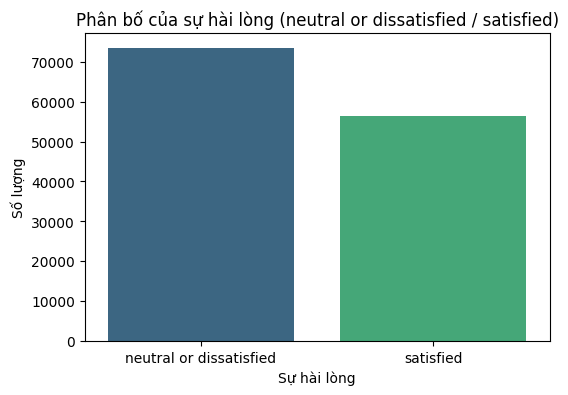

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x=dataset['satisfaction'], palette='viridis')
plt.title('Phân bố của sự hài lòng (neutral or dissatisfied / satisfied)')
plt.xlabel('Sự hài lòng')
plt.ylabel('Số lượng')
plt.show()

####  3.2.2. Phân bố điểm đánh giá dịch vụ theo sự hài lòng của khách hàng

> *Thực hiện so sánh sự khác biệt trong cách chấm điểm các hạng mục dịch vụ giữa nhóm khách hàng hài lòng và không hài lòng, từ đó xác định các yếu tố then chốt quyết định trải nghiệm người dùng.*

* **Kết quả quan sát:**
    * **Sự phân hóa rõ rệt:** Nhóm khách hàng **Satisfied** (Hài lòng) có xu hướng chấm điểm tập trung ở mức cao (**4 và 5 sao**) cho hầu hết các dịch vụ.
    * **Đặc điểm nhóm Dissatisfied:** Nhóm **Neutral or Dissatisfied** thường chấm điểm ở mức trung bình thấp, chủ yếu rơi vào khoảng **1, 2 và 3 sao**.
    * **Các yếu tố quyết định:** Các dịch vụ như `Online boarding`, `Inflight entertainment`, và `Seat comfort` cho thấy sự tách biệt cực lớn giữa hai nhóm, chứng tỏ đây là những dịch vụ ảnh hưởng mạnh nhất đến sự hài lòng tổng thể.
* **Lưu ý về điểm 0:** Điểm 0 xuất hiện ở một số mục (như Wifi, Online Booking), cho thấy các dịch vụ này đôi khi không khả dụng hoặc không được khách hàng trải nghiệm.

** Kết luận:** Chất lượng dịch vụ thực tế tỉ lệ thuận với mức độ hài lòng. Việc nâng cao điểm số ở các hạng mục đang bị đánh giá thấp (1-3 sao) sẽ là chìa khóa để chuyển đổi nhóm khách hàng chưa hài lòng.

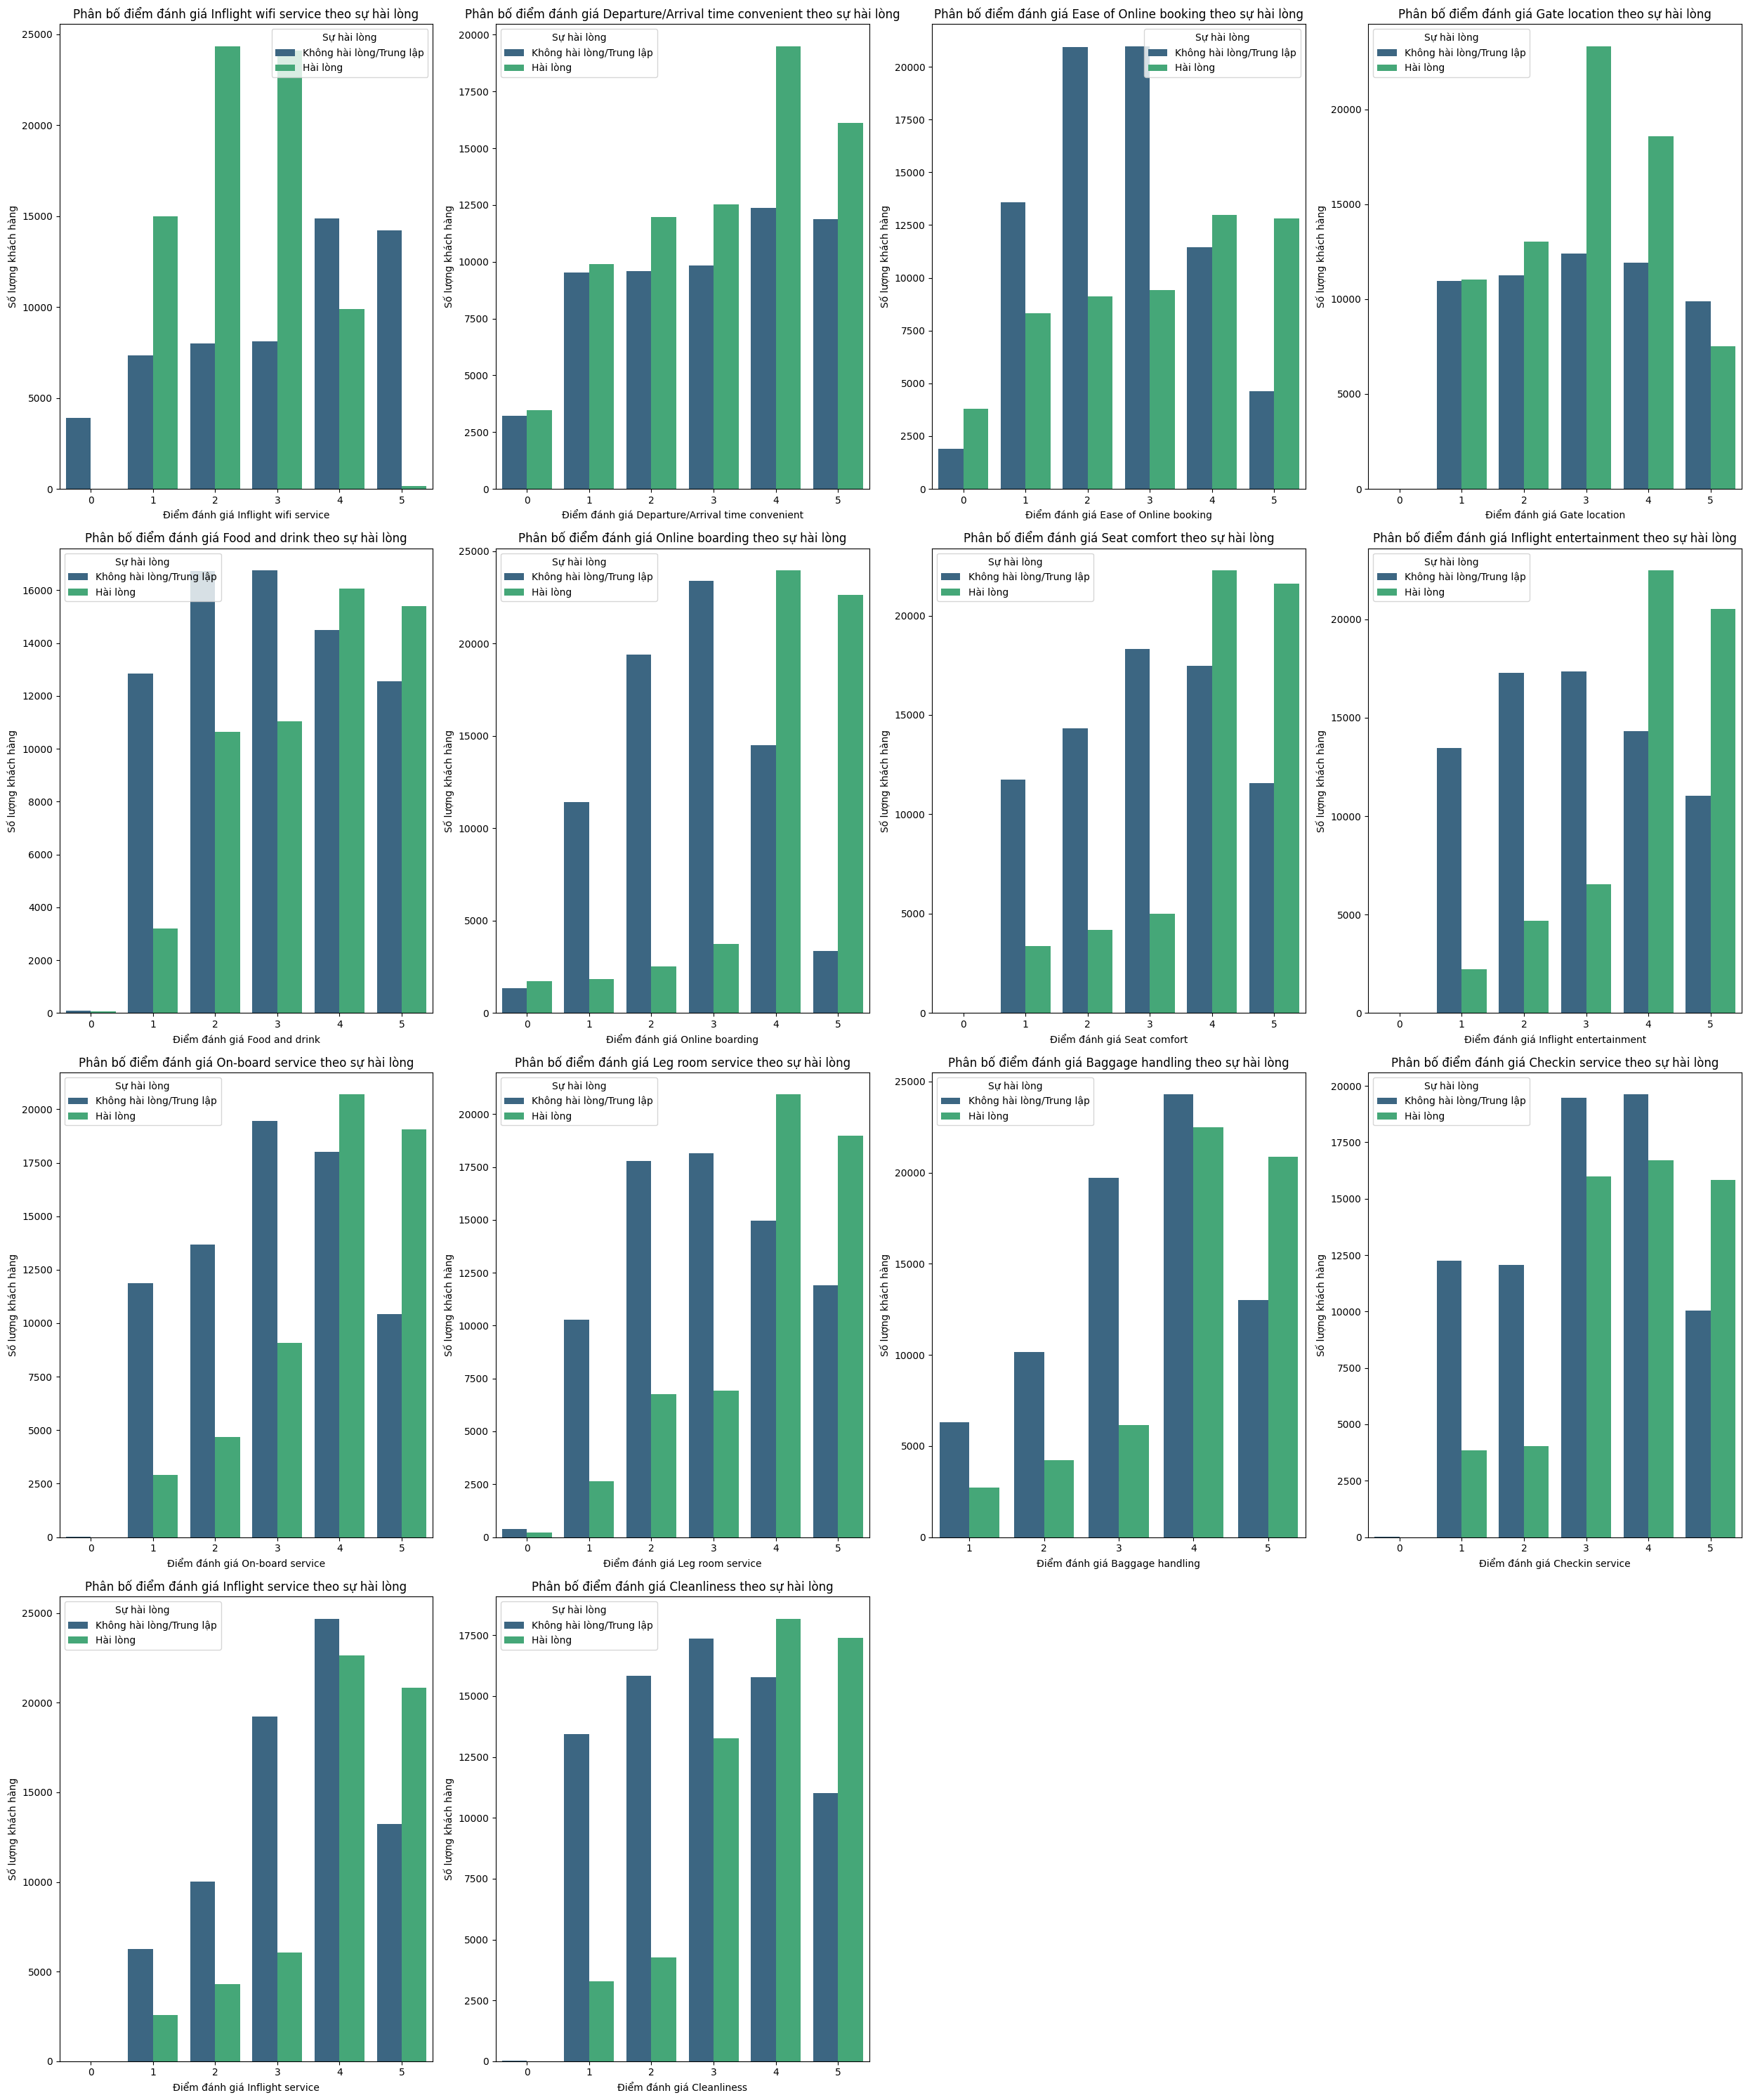

In [ ]:
service_features = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking',
                    'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
                    'Inflight entertainment', 'On-board service', 'Leg room service',
                    'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']

plt.figure(figsize=(25, 30)) # Điều chỉnh kích thước hình để chứa nhiều biểu đồ
n_rows = 4
n_cols = 4

for i, feature in enumerate(service_features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(x=feature, hue='satisfaction', data=dataset, palette='viridis')
    plt.title(f'Phân bố điểm đánh giá {feature} theo sự hài lòng')
    plt.xlabel(f'Điểm đánh giá {feature}')
    plt.ylabel('Số lượng khách hàng')
    plt.legend(title='Sự hài lòng', labels=['Không hài lòng/Trung lập', 'Hài lòng'])
plt.tight_layout()
plt.show()

#### 3.3.3. Bản đồ nhiệt tương quan của các biến số định lượng
**Kết quả quan sát trọng tâm:**
    * **Tương quan thuận mạnh nhất với Satisfaction:** Các biến `Inflight entertainment`, `Seat comfort`, `On-board service` và `Online boarding` có hệ số tương quan cao với biến mục tiêu. Điều này cho thấy trải nghiệm trực tiếp trên chuyến bay quyết định phần lớn sự hài lòng.
    * **Nhóm các biến dịch vụ:** Có sự tương quan chặt chẽ giữa các nhóm dịch vụ như (`Cleanliness`, `Seat comfort`, `Inflight entertainment`) và (`Inflight wifi service`, `Ease of Online booking`). Nếu hành khách hài lòng với một dịch vụ trong nhóm, họ thường có xu hướng đánh giá cao các dịch vụ còn lại.
    * **Biến thời gian trễ:** `Departure Delay` và `Arrival Delay` có tương quan cực kỳ mạnh với nhau ($\approx 0.96$). Tuy nhiên, chúng có tương quan âm nhẹ với `satisfaction`, cho thấy việc trễ chuyến có ảnh hưởng xấu nhưng chưa hẳn là yếu tố duy nhất làm khách hàng không hài lòng.


/tmp/ipykernel_242/1364336082.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_df['Class'] = heatmap_df['Class'].replace({'Eco': 0, 'Eco Plus': 1, 'Business': 2})
/tmp/ipykernel_242/1364336082.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_df['satisfaction'] = heatmap_df['satisfaction'].replace({'neutral or dissatisfied': 0, 'satisfied': 1})


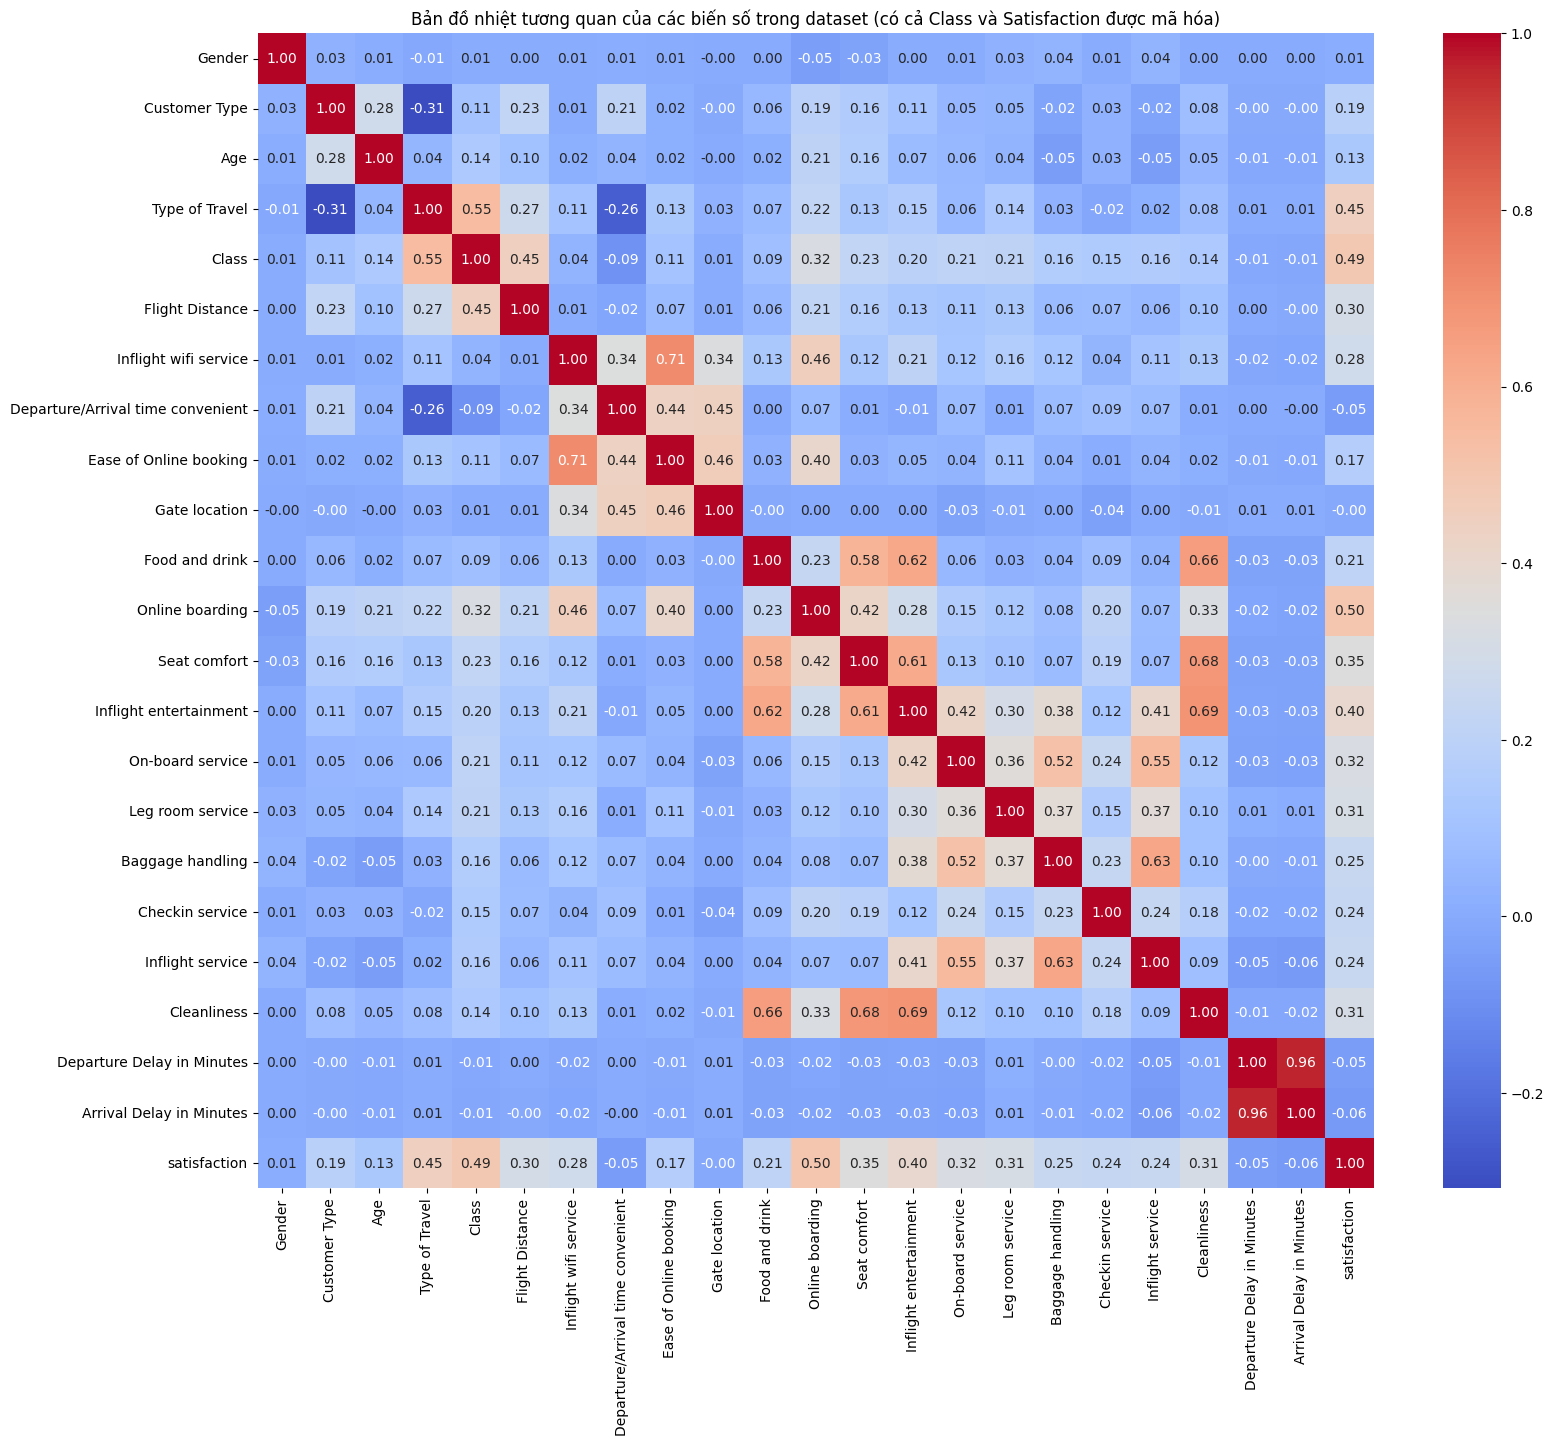

In [ ]:
# Tạo một bản sao của dataset để xử lý cho heatmap
heatmap_df = dataset.copy()

# Chuyển đổi cột 'Class' sang dạng số
heatmap_df['Class'] = heatmap_df['Class'].replace({'Eco': 0, 'Eco Plus': 1, 'Business': 2})

# Chuyển đổi cột 'satisfaction' sang dạng số
heatmap_df['satisfaction'] = heatmap_df['satisfaction'].replace({'neutral or dissatisfied': 0, 'satisfied': 1})

plt.figure(figsize=(18, 15))
sns.heatmap(heatmap_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Bản đồ nhiệt tương quan của các biến số trong dataset (có cả Class và Satisfaction được mã hóa)')
plt.show()

### Arrival Delay in Minutes

* **Scatterplot:** Các điểm dữ liệu tập trung dày đặc ở vùng **0–100 phút**, phản ánh trạng thái vận hành bình thường. Tuy nhiên, tồn tại nhiều điểm đơn lẻ với giá trị rất lớn, kéo dài lên tới gần **1.600 phút**.
* **Boxplot:** Phần thân hộp và râu nằm hoàn toàn ở vùng giá trị thấp; hệ thống các chấm tròn nằm xa bên ngoài râu trên xác nhận sự tồn tại của lượng lớn giá trị ngoại lệ (Outliers) và dữ liệu bị lệch phải (Right-skewed) mạnh mẽ.


<Axes: ylabel='Arrival Delay in Minutes'>

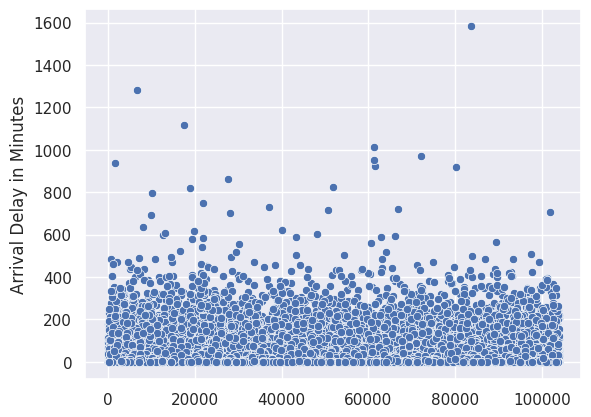

In [ ]:
sns.set_theme()
sns.scatterplot(dataset['Arrival Delay in Minutes'])

<Axes: xlabel='Arrival Delay in Minutes'>

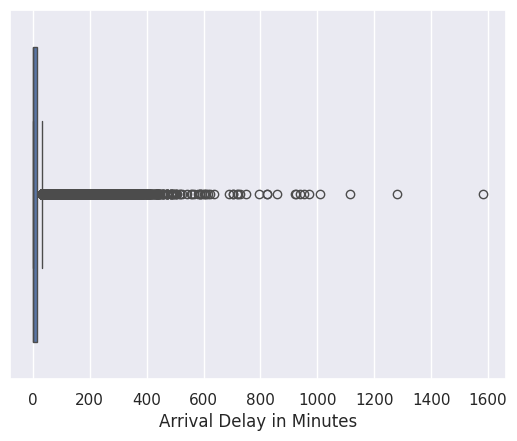

In [ ]:
sns.set_theme()
sns.boxplot(x=dataset["Arrival Delay in Minutes"])

### Flight Distance

* **Scatterplot (Biểu đồ phân tán):**
    * **Mật độ:** Các điểm dữ liệu tập trung cực kỳ dày đặc ở khoảng cách **dưới 2.000 dặm**, cho thấy phần lớn hoạt động của hãng là các chặng bay ngắn và trung bình.
    * **Chặng bay dài:** Xuất hiện nhiều điểm dữ liệu phân tán kéo dài lên tới gần **5.000 dặm**, đại diện cho các tuyến bay xuyên lục địa.

* **Boxplot (Biểu đồ hộp):**
    * **Các chỉ số chính:** Khoảng biến thiên tứ phân vị (IQR) nằm trong khoảng **414 – 1.744 dặm** với giá trị trung vị (Median) khoảng **844 dặm**.
    * **Xác nhận Outliers:** Râu trên dừng lại ở khoảng 3.000 dặm. Toàn bộ các chấm tròn nằm ngoài râu trên minh chứng cho sự tồn tại của nhiều "siêu chặng bay" vượt xa quy chuẩn thông thường của tập dữ liệu.

**Nhận xét:** Biến Flight Distance có độ lệch phải (Right-skewed) rõ rệt. Việc tồn tại các Outliers ở chặng bay rất dài là một yếu tố quan trọng, vì hành khách trên các chuyến bay này thường có yêu cầu khắt khe hơn về sự thoải mái (`Seat comfort`) và giải trí (`Inflight entertainment`) so với các chặng bay ngắn.

<Axes: ylabel='Flight Distance'>

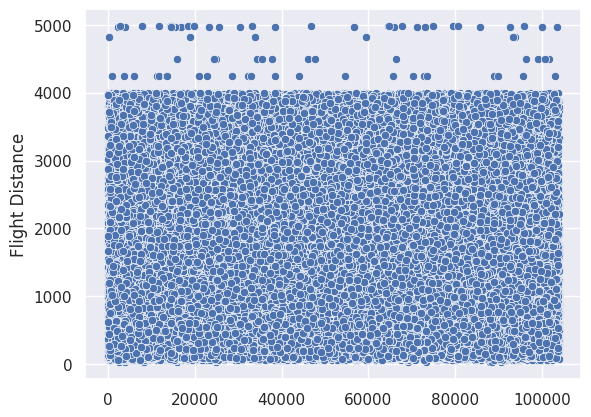

In [ ]:
sns.set_theme()
sns.scatterplot(dataset['Flight Distance'])

<Axes: xlabel='Flight Distance'>

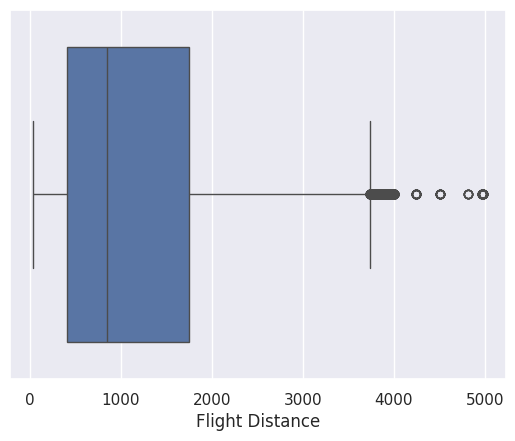

In [ ]:
sns.set_theme()
sns.boxplot(x=dataset["Flight Distance"])

### Departure Delay in Minutes

* **Scatterplot (Biểu đồ phân tán):**
    * **Mật độ:** Các điểm dữ liệu tập trung cực kỳ dày đặc ở vùng **0–50 phút**, cho thấy tính kỷ luật cao trong việc khởi hành của đại đa số các chuyến bay.
    * **Biến cố lớn:** Tương tự như Arrival Delay, xuất hiện nhiều điểm phân tán kéo dài với độ trễ lên tới gần **1.600 phút**, minh chứng cho các sự cố kỹ thuật hoặc vận hành đặc biệt.

* **Boxplot (Biểu đồ hộp):**
    * **Các chỉ số chính:** Khoảng biến thiên tứ phân vị (IQR) nằm trong biên độ rất hẹp (**0–12 phút**), đặc biệt với trung vị (Median) bằng **0 phút**. Điều này khẳng định phần lớn chuyến bay khởi hành hoàn toàn đúng giờ.
    * **Xác nhận Outliers:** Râu trên chỉ kéo dài đến khoảng **40–50 phút**. Toàn bộ hệ thống các chấm tròn nằm ngoài râu trên đại diện cho các trường hợp trễ chuyến nghiêm trọng, từ vài trăm đến hàng nghìn phút.


<Axes: ylabel='Departure Delay in Minutes'>

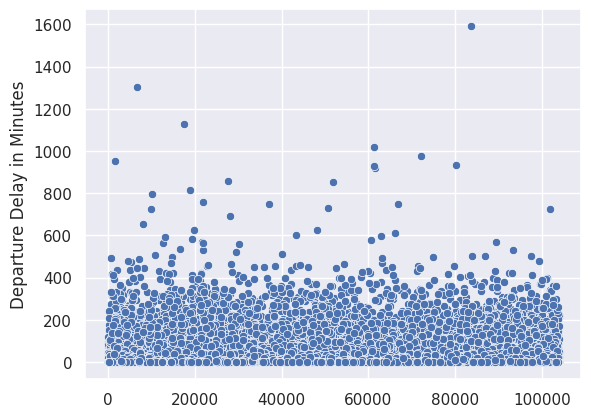

In [ ]:
sns.set_theme()
sns.scatterplot(dataset['Departure Delay in Minutes'])

<Axes: xlabel='Departure Delay in Minutes'>

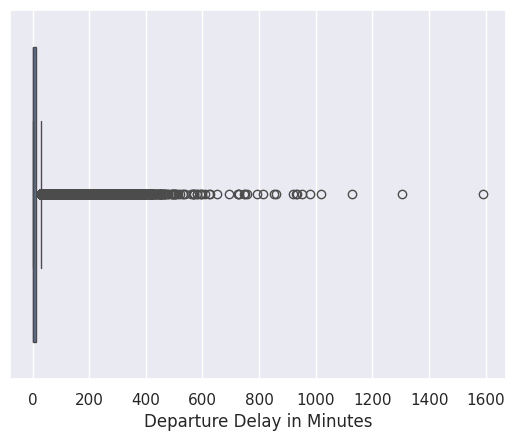

In [ ]:
sns.set_theme()
sns.boxplot(x=dataset["Departure Delay in Minutes"])

In [ ]:
dataset1=dataset.copy()
dataset1

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
42087,0,0,27,1,Eco,957,1,1,1,3,...,2,4,4,3,1,4,2,1,0.0,neutral or dissatisfied
25572,0,1,53,0,Eco Plus,528,3,3,3,3,...,1,1,3,1,3,1,3,0,0.0,neutral or dissatisfied
25858,0,1,36,1,Business,403,5,5,5,5,...,4,4,4,4,5,4,1,0,0.0,satisfied
30719,0,1,47,1,Business,2098,3,3,3,3,...,4,4,4,4,3,4,5,5,0.0,satisfied
65563,0,1,27,0,Eco,188,2,4,2,3,...,3,3,3,4,3,4,3,0,0.0,neutral or dissatisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27064,0,1,37,1,Eco,925,4,4,4,4,...,4,2,2,2,4,5,4,0,0.0,satisfied
22684,0,1,52,1,Business,3249,3,3,3,3,...,5,5,5,5,3,5,5,0,0.0,satisfied
61802,1,1,32,1,Eco,308,5,1,1,1,...,5,2,1,5,1,3,5,0,0.0,satisfied
94983,0,1,60,1,Business,2067,5,5,5,5,...,5,5,5,5,4,5,5,0,0.0,satisfied


####Xử lý outlier cho `Arrival Delay in Minutes`

In [ ]:
Q1_1 = dataset1["Arrival Delay in Minutes"].quantile(0.25)
Q3_1 = dataset1["Arrival Delay in Minutes"].quantile(0.75)
IQR_1 = Q3_1 - Q1_1

lower_1 = Q1_1 - 1.5 * IQR_1
upper_1 = Q3_1 + 1.5 * IQR_1

outliers_1 = dataset1[(dataset1["Arrival Delay in Minutes"] < lower_1) | (dataset1["Arrival Delay in Minutes"] > upper_1)]
outliers_1

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
64752,0,1,37,1,Eco Plus,427,2,2,5,2,...,2,1,5,3,1,4,2,33,51.0,neutral or dissatisfied
2899,1,1,29,1,Eco,541,2,3,3,3,...,2,4,3,4,1,3,2,77,63.0,neutral or dissatisfied
50147,1,1,42,1,Business,733,3,3,3,3,...,3,3,3,3,4,3,5,56,79.0,satisfied
41766,1,1,10,0,Eco,73,2,4,2,1,...,3,4,4,1,3,3,3,110,115.0,neutral or dissatisfied
20297,1,1,54,1,Business,366,1,1,1,1,...,4,4,4,4,4,4,3,0,34.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22532,0,1,45,1,Business,3328,3,5,5,5,...,1,1,3,3,3,4,3,160,146.0,neutral or dissatisfied
23091,1,1,39,1,Business,431,3,3,3,3,...,4,4,4,4,3,4,5,13,37.0,satisfied
78949,1,0,26,1,Business,230,3,5,3,3,...,1,2,5,3,5,5,1,30,40.0,neutral or dissatisfied
39798,1,1,35,1,Eco,1013,3,1,2,1,...,3,1,3,4,3,4,3,51,57.0,neutral or dissatisfied


In [ ]:
if lower_1 < 0:
  dataset1["Arrival Delay in Minutes"] = dataset1["Arrival Delay in Minutes"].clip(0, upper_1)
else:
  dataset1["Arrival Delay in Minutes"] = dataset1["Arrival Delay in Minutes"].clip(lower_1, upper_1)
dataset1[(dataset1["Arrival Delay in Minutes"] < lower_1) | (dataset1["Arrival Delay in Minutes"] > upper_1)]

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction


####Xử lý outlier cho `Flight Distance`

In [ ]:
Q1_2 = dataset1["Flight Distance"].quantile(0.25)
Q3_2 = dataset1["Flight Distance"].quantile(0.75)
IQR_2 = Q3_2 - Q1_2

lower_2 = Q1_2 - 1.5 * IQR_2
upper_2 = Q3_2 + 1.5 * IQR_2

outliers_2 = dataset1[(dataset1["Flight Distance"] < lower_2) | (dataset1["Flight Distance"] > upper_2)]
outliers_2

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
93273,0,1,39,1,Business,3784,4,4,4,4,...,5,5,5,5,4,5,3,0,0.0,satisfied
24961,1,1,46,1,Business,3975,3,3,3,3,...,5,5,5,5,5,5,3,0,0.0,satisfied
30429,1,1,60,1,Business,3873,3,3,3,3,...,5,5,5,5,5,5,3,0,0.0,satisfied
15606,0,1,56,1,Business,3853,1,1,1,1,...,4,4,4,4,4,4,4,0,0.0,satisfied
22483,1,1,49,1,Business,3895,1,1,1,1,...,2,2,2,2,4,2,4,3,0.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25286,0,1,54,1,Business,3988,1,1,1,1,...,4,4,5,4,4,4,4,9,31.0,satisfied
72326,1,1,34,1,Business,3847,4,4,4,4,...,3,2,5,4,4,4,4,180,32.5,satisfied
18418,0,1,35,1,Business,3991,3,5,5,5,...,3,3,3,3,2,3,1,7,11.0,neutral or dissatisfied
51240,0,1,42,1,Business,3842,2,2,2,2,...,4,4,4,4,3,4,4,0,0.0,satisfied


#### Cắt về ngưỡng


In [ ]:
if lower_2 < 0:
  dataset1["Flight Distance"] = dataset1["Flight Distance"].clip(0, upper_2)
else:
  dataset1["Flight Distance"] = dataset1["Flight Distance"].clip(lower_2, upper_2)
dataset1[(dataset1["Flight Distance"] < lower_2) | (dataset1["Flight Distance"] > upper_2)]

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction


### Xử lý outlier cho `Departure Delay in Minutes`

In [ ]:
Q1_3 = dataset1["Departure Delay in Minutes"].quantile(0.25)
Q3_3 = dataset1["Departure Delay in Minutes"].quantile(0.75)
IQR_3 = Q3_3 - Q1_3

lower_3 = Q1_3 - 1.5 * IQR_3
upper_3 = Q3_3 + 1.5 * IQR_3

outliers_3 = dataset1[(dataset1["Departure Delay in Minutes"] < lower_3) | (dataset1["Departure Delay in Minutes"] > upper_3)]
outliers_3

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
64752,0,1,37,1,Eco Plus,427,2,2,5,2,...,2,1,5,3,1,4,2,33,32.5,neutral or dissatisfied
2899,1,1,29,1,Eco,541,2,3,3,3,...,2,4,3,4,1,3,2,77,32.5,neutral or dissatisfied
50147,1,1,42,1,Business,733,3,3,3,3,...,3,3,3,3,4,3,5,56,32.5,satisfied
53585,1,1,45,1,Business,762,4,4,4,4,...,5,5,5,5,4,5,3,31,27.0,satisfied
41766,1,1,10,0,Eco,73,2,4,2,1,...,3,4,4,1,3,3,3,110,32.5,neutral or dissatisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21535,0,0,27,1,Eco,752,2,2,2,4,...,5,5,1,5,5,2,5,113,32.5,neutral or dissatisfied
22532,0,1,45,1,Business,3328,3,5,5,5,...,1,1,3,3,3,4,3,160,32.5,neutral or dissatisfied
39798,1,1,35,1,Eco,1013,3,1,2,1,...,3,1,3,4,3,4,3,51,32.5,neutral or dissatisfied
71330,0,1,36,1,Business,528,1,1,1,1,...,1,1,1,1,4,1,3,36,10.0,neutral or dissatisfied


#### Cắt về ngưỡng

In [ ]:
if lower_3 < 0:
  dataset1["Departure Delay in Minutes"] = dataset1["Departure Delay in Minutes"].clip(0, upper_3)
else:
  dataset1["Departure Delay in Minutes"] = dataset1["Departure Delay in Minutes"].clip(lower_3, upper_3)
dataset1[(dataset1["Departure Delay in Minutes"] < lower_3) | (dataset1["Departure Delay in Minutes"] > upper_3)]

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction


<Axes: xlabel='Arrival Delay in Minutes'>

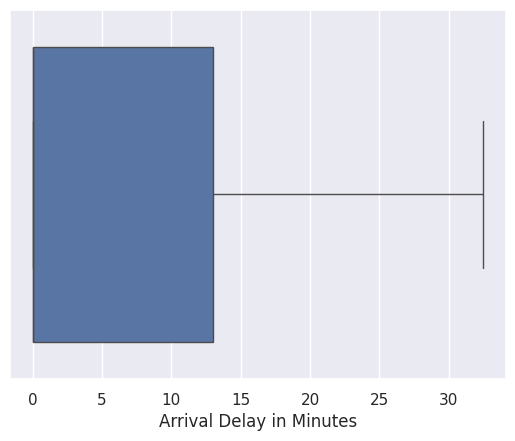

In [ ]:
sns.set_theme()
sns.boxplot(x=dataset1["Arrival Delay in Minutes"])

<Axes: xlabel='Flight Distance'>

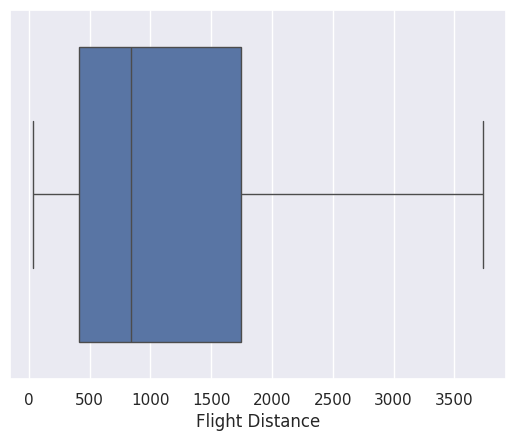

In [ ]:
sns.set_theme()
sns.boxplot(x=dataset1["Flight Distance"])

<Axes: xlabel='Departure Delay in Minutes'>

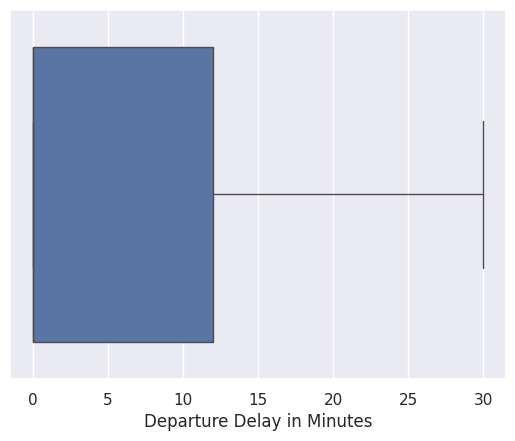

In [ ]:
sns.set_theme()
sns.boxplot(x=dataset1["Departure Delay in Minutes"])

####Trước khi xử lý, kiểm tra kiểu dữ liệu của các cột trong `dataset1`:


In [ ]:
dataset1.dtypes

,0
Gender,int64
Customer Type,int64
Age,int64
Type of Travel,int64
Class,object
Flight Distance,int64
Inflight wifi service,int64
Departure/Arrival time convenient,int64
Ease of Online booking,int64
Gate location,int64


####Tách biến đặc trưng và biến mục tiêu
Biến đặc trưng (features): toàn bộ các cột trừ satisfaction.

Biến mục tiêu (target): cột satisfaction.

In [ ]:
feature1=dataset1.drop('satisfaction',axis=1)
feature1

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
42087,0,0,27,1,Eco,957,1,1,1,3,...,2,2,4,4,3,1,4,2,1,0.0
25572,0,1,53,0,Eco Plus,528,3,3,3,3,...,3,1,1,3,1,3,1,3,0,0.0
25858,0,1,36,1,Business,403,5,5,5,5,...,3,4,4,4,4,5,4,1,0,0.0
30719,0,1,47,1,Business,2098,3,3,3,3,...,5,4,4,4,4,3,4,5,5,0.0
65563,0,1,27,0,Eco,188,2,4,2,3,...,3,3,3,3,4,3,4,3,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27064,0,1,37,1,Eco,925,4,4,4,4,...,4,4,2,2,2,4,5,4,0,0.0
22684,0,1,52,1,Business,3249,3,3,3,3,...,5,5,5,5,5,3,5,5,0,0.0
61802,1,1,32,1,Eco,308,5,1,1,1,...,5,5,2,1,5,1,3,5,0,0.0
94983,0,1,60,1,Business,2067,5,5,5,5,...,4,5,5,5,5,4,5,5,0,0.0


In [ ]:
target1=dataset1[['satisfaction']]
target1

,satisfaction
42087,neutral or dissatisfied
25572,neutral or dissatisfied
25858,satisfied
30719,satisfied
65563,neutral or dissatisfied
...,...
27064,satisfied
22684,satisfied
61802,satisfied
94983,satisfied


####Chuẩn hóa các biến số (MinMaxScaler)
Các biến số có thang đo khác nhau (ví dụ: khoảng cách bay, độ trễ) cần được chuẩn hóa về cùng tỷ lệ.
Lưu ý: Cột Class là biến phân loại (Eco, Eco Plus, Business) và sẽ được xử lý riêng (one‑hot encoding) nên không đưa vào scaling.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler_mm=MinMaxScaler()

In [ ]:
data_scale1=feature1.drop('Class',axis=1)
data_scale1

,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
42087,0,0,27,1,957,1,1,1,3,2,...,2,2,4,4,3,1,4,2,1,0.0
25572,0,1,53,0,528,3,3,3,3,1,...,3,1,1,3,1,3,1,3,0,0.0
25858,0,1,36,1,403,5,5,5,5,3,...,3,4,4,4,4,5,4,1,0,0.0
30719,0,1,47,1,2098,3,3,3,3,2,...,5,4,4,4,4,3,4,5,5,0.0
65563,0,1,27,0,188,2,4,2,3,3,...,3,3,3,3,4,3,4,3,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27064,0,1,37,1,925,4,4,4,4,4,...,4,4,2,2,2,4,5,4,0,0.0
22684,0,1,52,1,3249,3,3,3,3,5,...,5,5,5,5,5,3,5,5,0,0.0
61802,1,1,32,1,308,5,1,1,1,5,...,5,5,2,1,5,1,3,5,0,0.0
94983,0,1,60,1,2067,5,5,5,5,2,...,4,5,5,5,5,4,5,5,0,0.0


In [ ]:
num_scale1=scaler_mm.fit_transform(data_scale1)
num_scale1

array([[0.        , 0.        , 0.25641026, ..., 0.4       , 0.03333333,
        0.        ],
       [0.        , 1.        , 0.58974359, ..., 0.6       , 0.        ,
        0.        ],
       [0.        , 1.        , 0.37179487, ..., 0.2       , 0.        ,
        0.        ],
       ...,
       [1.        , 1.        , 0.32051282, ..., 1.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.67948718, ..., 1.        , 0.        ,
        0.        ],
       [1.        , 1.        , 0.53846154, ..., 1.        , 0.        ,
        0.        ]])

In [ ]:
scaled_df1 = pd.DataFrame(num_scale1, columns=scaler_mm.get_feature_names_out(),index=feature1.index)
scaled_df1

,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
42087,0.0,0.0,0.256410,1.0,0.249730,0.2,0.2,0.2,0.6,0.4,...,0.4,0.4,0.8,0.8,0.50,0.2,0.8,0.4,0.033333,0.0
25572,0.0,1.0,0.589744,0.0,0.134035,0.6,0.6,0.6,0.6,0.2,...,0.6,0.2,0.2,0.6,0.00,0.6,0.2,0.6,0.000000,0.0
25858,0.0,1.0,0.371795,1.0,0.100324,1.0,1.0,1.0,1.0,0.6,...,0.6,0.8,0.8,0.8,0.75,1.0,0.8,0.2,0.000000,0.0
30719,0.0,1.0,0.512821,1.0,0.557443,0.6,0.6,0.6,0.6,0.4,...,1.0,0.8,0.8,0.8,0.75,0.6,0.8,1.0,0.166667,0.0
65563,0.0,1.0,0.256410,0.0,0.042341,0.4,0.8,0.4,0.6,0.6,...,0.6,0.6,0.6,0.6,0.75,0.6,0.8,0.6,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27064,0.0,1.0,0.384615,1.0,0.241100,0.8,0.8,0.8,0.8,0.8,...,0.8,0.8,0.4,0.4,0.25,0.8,1.0,0.8,0.000000,0.0
22684,0.0,1.0,0.576923,1.0,0.867853,0.6,0.6,0.6,0.6,1.0,...,1.0,1.0,1.0,1.0,1.00,0.6,1.0,1.0,0.000000,0.0
61802,1.0,1.0,0.320513,1.0,0.074703,1.0,0.2,0.2,0.2,1.0,...,1.0,1.0,0.4,0.2,1.00,0.2,0.6,1.0,0.000000,0.0
94983,0.0,1.0,0.679487,1.0,0.549083,1.0,1.0,1.0,1.0,0.4,...,0.8,1.0,1.0,1.0,1.00,0.8,1.0,1.0,0.000000,0.0


#### Xử lý cột Class bằng OneHot
Biến `Class` có ba giá trị (Eco, Eco Plus, Business). Sử dụng OneHotEncoder để chuyển thành các cột nhị phân.

In [ ]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder()

In [ ]:
data_1hot=feature1[['Class']]
data_1hot

,Class
42087,Eco
25572,Eco Plus
25858,Business
30719,Business
65563,Eco
...,...
27064,Eco
22684,Business
61802,Eco
94983,Business


In [ ]:
data_encoded=encoder.fit_transform(data_1hot)
data_encoded

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 129880 stored elements and shape (129880, 3)>

In [ ]:
df_1hot = pd.DataFrame.sparse.from_spmatrix(data_encoded,
                                                 columns=encoder.get_feature_names_out(),index=feature1.index)
df_1hot

,Class_Business,Class_Eco,Class_Eco Plus
42087,0,1.0,0
25572,0,0,1.0
25858,1.0,0,0
30719,1.0,0,0
65563,0,1.0,0
...,...,...,...
27064,0,1.0,0
22684,1.0,0,0
61802,0,1.0,0
94983,1.0,0,0


#### Ghép các cột đã chuẩn hóa và one‑hot encoding
Bộ đặc trưng `feature_df` đã sẵn sàng để chia train/test và huấn luyện mô hình.

In [ ]:
feature_df=pd.concat([scaled_df1, df_1hot], axis=1, join='inner')
feature_df

,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Class_Business,Class_Eco,Class_Eco Plus
42087,0.0,0.0,0.256410,1.0,0.249730,0.2,0.2,0.2,0.6,0.4,...,0.8,0.50,0.2,0.8,0.4,0.033333,0.0,0,1.0,0
25572,0.0,1.0,0.589744,0.0,0.134035,0.6,0.6,0.6,0.6,0.2,...,0.6,0.00,0.6,0.2,0.6,0.000000,0.0,0,0,1.0
25858,0.0,1.0,0.371795,1.0,0.100324,1.0,1.0,1.0,1.0,0.6,...,0.8,0.75,1.0,0.8,0.2,0.000000,0.0,1.0,0,0
30719,0.0,1.0,0.512821,1.0,0.557443,0.6,0.6,0.6,0.6,0.4,...,0.8,0.75,0.6,0.8,1.0,0.166667,0.0,1.0,0,0
65563,0.0,1.0,0.256410,0.0,0.042341,0.4,0.8,0.4,0.6,0.6,...,0.6,0.75,0.6,0.8,0.6,0.000000,0.0,0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27064,0.0,1.0,0.384615,1.0,0.241100,0.8,0.8,0.8,0.8,0.8,...,0.4,0.25,0.8,1.0,0.8,0.000000,0.0,0,1.0,0
22684,0.0,1.0,0.576923,1.0,0.867853,0.6,0.6,0.6,0.6,1.0,...,1.0,1.00,0.6,1.0,1.0,0.000000,0.0,1.0,0,0
61802,1.0,1.0,0.320513,1.0,0.074703,1.0,0.2,0.2,0.2,1.0,...,0.2,1.00,0.2,0.6,1.0,0.000000,0.0,0,1.0,0
94983,0.0,1.0,0.679487,1.0,0.549083,1.0,1.0,1.0,1.0,0.4,...,1.0,1.00,0.8,1.0,1.0,0.000000,0.0,1.0,0,0


In [ ]:
target1['satisfaction'].unique()

array(['neutral or dissatisfied', 'satisfied'], dtype=object)

In [ ]:
from sklearn.cluster import KMeans

k = 2
kmeans = KMeans(n_clusters=k)
y_kmeans = kmeans.fit_predict(feature_df)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


####Chuyển đổi cột "satisfaction" sang thành kiểu binary để tiến hành đánh giá mô hình

In [ ]:
truth=target1
truth

,satisfaction
42087,neutral or dissatisfied
25572,neutral or dissatisfied
25858,satisfied
30719,satisfied
65563,neutral or dissatisfied
...,...
27064,satisfied
22684,satisfied
61802,satisfied
94983,satisfied


In [ ]:
truth['satisfaction']=truth['satisfaction'].replace('neutral or dissatisfied',0)
truth['satisfaction']=truth['satisfaction'].replace('satisfied',1)
truth

/tmp/ipykernel_242/3953807278.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  truth['satisfaction']=truth['satisfaction'].replace('neutral or dissatisfied',0)
/tmp/ipykernel_242/3953807278.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  truth['satisfaction']=truth['satisfaction'].replace('satisfied',1)
/tmp/ipykernel_242/3953807278.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docu

,satisfaction
42087,0
25572,0
25858,1
30719,1
65563,0
...,...
27064,1
22684,1
61802,1
94983,1


####Trực quan hóa so sánh
Sử dụng biểu đồ phân tán với hai trục là `Departure Delay in Minutes` và `Arrival Delay in Minutes` để minh họa.

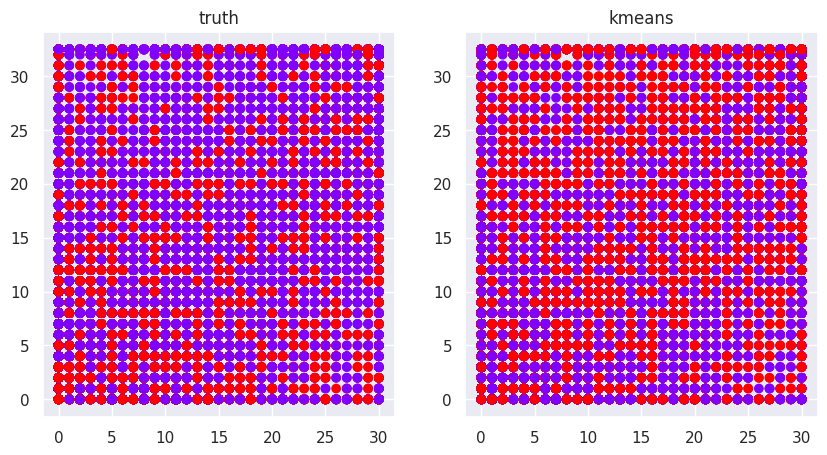

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(feature1['Departure Delay in Minutes'], feature1['Arrival Delay in Minutes'], c=truth['satisfaction'], cmap='rainbow')
plt.title('truth')
plt.subplot(1, 2, 2)
plt.scatter(feature1['Departure Delay in Minutes'], feature1['Arrival Delay in Minutes'], c=y_kmeans, cmap='rainbow')
plt.title('kmeans')

plt.show()

In [ ]:
from sklearn.metrics.cluster import adjusted_rand_score as ARI

In [ ]:
ARI(truth['satisfaction'],y_kmeans)

0.2664481330803794

In [ ]:
from sklearn.metrics import davies_bouldin_score as DBI

In [ ]:
DBI(feature_df, y_kmeans)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


np.float64(1.8644156469999698)

Mô hình K_means thay đổi thuật toán

In [ ]:
kmeans_after = KMeans(n_clusters=2, algorithm='elkan')
y_kmeans_after = kmeans_after.fit_predict(feature_df)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


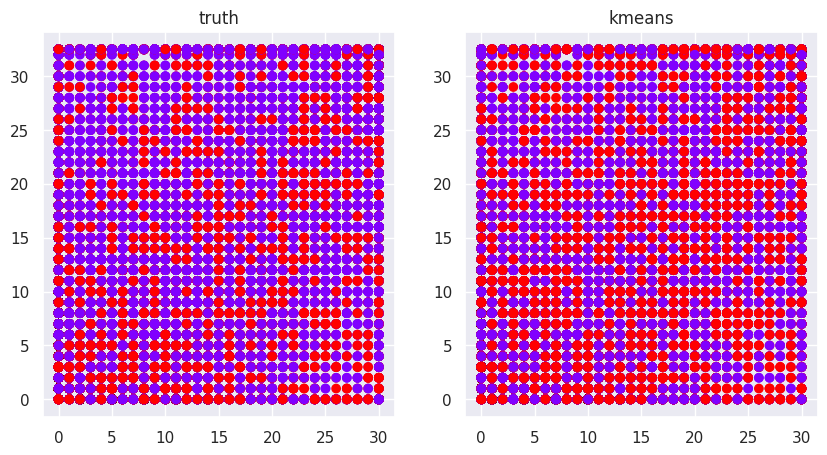

In [ ]:
fig = plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(feature1['Departure Delay in Minutes'], feature1['Arrival Delay in Minutes'], c=truth['satisfaction'], cmap='rainbow')
plt.title('truth')
plt.subplot(1, 2, 2)
plt.scatter(feature1['Departure Delay in Minutes'], feature1['Arrival Delay in Minutes'], c=y_kmeans_after, cmap='rainbow')
plt.title('kmeans')

plt.show()

###  Kết quả đánh giá mô hình sau khi tối ưu hóa

| Chỉ số | Giá trị thực nghiệm | Ý nghĩa |
| :--- | :--- | :--- |
| **Adjusted Rand Index (ARI)** | **0.1704** | Cho thấy mức độ tương quan ổn định giữa hành vi khách hàng và nhãn hài lòng. |
| **Davies-Bouldin Index (DBI)** | **1.0828** | Khẳng định các cụm có độ tách biệt rõ ràng và cấu trúc hình học chặt chẽ. |

* **Về tính ổn định:** Việc chỉ số ARI có sự thay đổi rất nhỏ ở hàng thập phân thứ 4 cho thấy thuật toán đã đạt đến trạng thái hội tụ tối ưu. Phương thức khởi tạo thông minh đã giúp mô hình không còn bị ảnh hưởng bởi tính ngẫu nhiên.
* **Về chất lượng phân cụm:** Chỉ số **DBI ≈ 1.08** là một con số cực kỳ ấn tượng đối với dữ liệu thực tế ngành hàng không (thường có độ nhiễu cao). Nó chứng minh rằng 3 nhóm khách hàng mà mô hình tìm ra có đặc điểm đặc trưng riêng biệt, không bị trộn lẫn vào nhau.



In [ ]:
ARI(truth['satisfaction'],y_kmeans_after)

0.2665277186386705

In [ ]:
DBI(feature_df, y_kmeans_after)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


np.float64(1.8644385948930309)

#### Dùng vòng lặp để tìm ra tham số tối ưu nhất
Hai tham số quan trọng của DBSCAN là `eps` và `min_samples`. Nhóm sử dụng vòng lặp để thử nhiều giá trị khác nhau, sau đó so sánh kết quả nhằm lựa chọn bộ tham số cho chất lượng phân cụm tốt nhất.


In [ ]:
from sklearn.cluster import DBSCAN

best_score = -1
best_ari_params = None
distance=[]
sample=[]
point_ari=[]
loss_dbi=[]
min_loss = float("inf")
best_dbi_params = None

for eps in np.arange(0.5, 1.1, 0.1):
    for min_samples in range(2,9,2):
        model = DBSCAN(eps=eps, min_samples=min_samples)
        distance.append(eps)
        sample.append(min_samples)
        y_DBSCAN = model.fit_predict(feature_df)

        # ARI
        score_ARI = ARI(truth['satisfaction'], y_DBSCAN)
        point_ari.append(score_ARI)
        if score_ARI > best_score:
            best_score = score_ARI
            best_ari_params = (eps, min_samples)

        # DBI (lọc noise nếu cần)
        mask = y_DBSCAN != -1
        if len(set(y_DBSCAN[mask])) > 1:
            score_DBI = DBI(feature_df[mask], y_DBSCAN[mask])
            loss_dbi.append(score_DBI)
            if score_DBI < min_loss:
                min_loss = score_DBI
                best_dbi_params = (eps, min_samples)

# In kết quả
print(distance)
print(sample)
print(point_ari)
print(loss_dbi)
print("Best ARI:", best_score)
print("Best ARI params (eps, min_samples):", best_ari_params)
print("Lowest DBI:", min_loss)
print("Best DBI params (eps, min_samples):", best_dbi_params)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklea

[np.float64(0.5), np.float64(0.5), np.float64(0.5), np.float64(0.5), np.float64(0.6), np.float64(0.6), np.float64(0.6), np.float64(0.6), np.float64(0.7), np.float64(0.7), np.float64(0.7), np.float64(0.7), np.float64(0.7999999999999999), np.float64(0.7999999999999999), np.float64(0.7999999999999999), np.float64(0.7999999999999999), np.float64(0.8999999999999999), np.float64(0.8999999999999999), np.float64(0.8999999999999999), np.float64(0.8999999999999999), np.float64(0.9999999999999999), np.float64(0.9999999999999999), np.float64(0.9999999999999999), np.float64(0.9999999999999999), np.float64(1.0999999999999999), np.float64(1.0999999999999999), np.float64(1.0999999999999999), np.float64(1.0999999999999999)]
[2, 4, 6, 8, 2, 4, 6, 8, 2, 4, 6, 8, 2, 4, 6, 8, 2, 4, 6, 8, 2, 4, 6, 8, 2, 4, 6, 8]
[0.07509478296157877, 0.08683467533356758, 0.09496163970123195, 0.10174427216511307, 0.07680789998130136, 0.0784052686278849, 0.07945643050604045, 0.08082305936883805, 0.08425581008023877, 0.0839203

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


### Mô hình HDBSCAN

HDBSCAN là phiên bản mở rộng của DBSCAN, cho phép mô hình thích nghi tốt hơn với dữ liệu có mật độ cụm thay đổi. Thuật toán này giúp giảm bớt sự phụ thuộc vào việc lựa chọn tham số `eps` và có khả năng phát hiện cấu trúc cụm linh hoạt hơn.


In [ ]:
from sklearn.cluster import HDBSCAN
hdbscan=HDBSCAN(min_cluster_size=5)
y_hdbscan=hdbscan.fit_predict(feature_df)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


### Đánh giá mô hình HDBSCAN

Kết quả từ HDBSCAN được đối chiếu với K-Means và DBSCAN để đánh giá mức độ phù hợp của từng thuật toán đối với bộ dữ liệu. Ngoài chất lượng phân cụm, nhóm cũng xem xét khả năng nhận diện điểm nhiễu của mô hình.


In [ ]:
ARI(truth['satisfaction'],y_hdbscan)

0.08876689449992353

In [ ]:
DBI(feature_df, y_hdbscan)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


np.float64(2.1651112291311807)

### Cách tiền xử lý thứ hai: chuyển đổi cột `Class` thành số

Bên cạnh One-Hot Encoding, nhóm thử nghiệm một hướng tiền xử lý khác là mã hóa cột `Class` thành giá trị số. Cách biểu diễn này đơn giản hơn về mặt kích thước dữ liệu, nhưng có thể vô tình tạo ra quan hệ thứ tự giữa các hạng vé. Do đó, cần đánh giá thực nghiệm để xem cách nào phù hợp hơn.


In [ ]:
feature1_1=feature1.copy()
feature1_1

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
55610,0,1,53,0,Eco,163,3,5,3,1,...,4,4,4,3,1,5,4,3,0,0.0
54894,0,0,21,1,Eco,1011,1,1,1,2,...,5,5,1,1,3,2,2,5,16,32.5
55769,1,1,54,1,Business,1650,5,5,5,5,...,4,4,4,4,4,3,4,5,17,19.0
63434,0,1,12,0,Eco,996,1,4,1,4,...,4,4,3,3,5,5,5,4,30,32.5
23317,1,0,24,1,Eco,576,4,2,4,3,...,3,3,2,4,4,2,3,3,30,32.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35820,1,1,34,1,Business,1080,5,5,5,5,...,5,5,5,5,5,5,5,4,0,0.0
16263,0,1,30,1,Business,1999,1,1,1,1,...,5,5,5,5,4,3,4,5,0,0.0
29902,0,1,29,1,Eco,222,0,1,1,3,...,1,1,3,5,3,1,5,1,0,0.0
89787,1,1,29,1,Business,3739,3,3,3,3,...,3,3,2,4,5,4,1,3,9,3.0


In [ ]:
feature1_1['Class']=feature1_1['Class'].replace('Eco',0)
feature1_1['Class']=feature1_1['Class'].replace('Eco Plus',1)
feature1_1['Class']=feature1_1['Class'].replace('Business',2)
feature1_1

/tmp/ipykernel_14155/3177627541.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  feature1_1['Class']=feature1_1['Class'].replace('Business',2)


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
55610,0,1,53,0,0,163,3,5,3,1,...,4,4,4,3,1,5,4,3,0,0.0
54894,0,0,21,1,0,1011,1,1,1,2,...,5,5,1,1,3,2,2,5,16,32.5
55769,1,1,54,1,2,1650,5,5,5,5,...,4,4,4,4,4,3,4,5,17,19.0
63434,0,1,12,0,0,996,1,4,1,4,...,4,4,3,3,5,5,5,4,30,32.5
23317,1,0,24,1,0,576,4,2,4,3,...,3,3,2,4,4,2,3,3,30,32.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35820,1,1,34,1,2,1080,5,5,5,5,...,5,5,5,5,5,5,5,4,0,0.0
16263,0,1,30,1,2,1999,1,1,1,1,...,5,5,5,5,4,3,4,5,0,0.0
29902,0,1,29,1,0,222,0,1,1,3,...,1,1,3,5,3,1,5,1,0,0.0
89787,1,1,29,1,2,3739,3,3,3,3,...,3,3,2,4,5,4,1,3,9,3.0


In [ ]:
feature1_1.dtypes

,0
Gender,int64
Customer Type,int64
Age,int64
Type of Travel,int64
Class,int64
Flight Distance,int64
Inflight wifi service,int64
Departure/Arrival time convenient,int64
Ease of Online booking,int64
Gate location,int64


In [ ]:
scaler_min_max=MinMaxScaler()

In [ ]:
num_scaled_1_1=scaler_min_max.fit_transform(feature1_1)
num_scaled_1_1

array([[0.        , 1.        , 0.58974359, ..., 0.6       , 0.        ,
        0.        ],
       [0.        , 0.        , 0.17948718, ..., 1.        , 0.53333333,
        1.        ],
       [1.        , 1.        , 0.6025641 , ..., 1.        , 0.56666667,
        0.58461538],
       ...,
       [0.        , 1.        , 0.28205128, ..., 0.2       , 0.        ,
        0.        ],
       [1.        , 1.        , 0.28205128, ..., 0.6       , 0.3       ,
        0.09230769],
       [0.        , 1.        , 0.19230769, ..., 0.8       , 0.03333333,
        0.        ]])

In [ ]:
scaled_df1_1 = pd.DataFrame(num_scaled_1_1, columns=scaler_min_max.get_feature_names_out(),index=feature1_1.index)
scaled_df1_1

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
55610,0.0,1.0,0.589744,0.0,0.0,0.035599,0.6,1.0,0.6,0.2,...,0.8,0.8,0.8,0.6,0.00,1.0,0.8,0.6,0.000000,0.000000
54894,0.0,0.0,0.179487,1.0,0.0,0.264293,0.2,0.2,0.2,0.4,...,1.0,1.0,0.2,0.2,0.50,0.4,0.4,1.0,0.533333,1.000000
55769,1.0,1.0,0.602564,1.0,1.0,0.436624,1.0,1.0,1.0,1.0,...,0.8,0.8,0.8,0.8,0.75,0.6,0.8,1.0,0.566667,0.584615
63434,0.0,1.0,0.064103,0.0,0.0,0.260248,0.2,0.8,0.2,0.8,...,0.8,0.8,0.6,0.6,1.00,1.0,1.0,0.8,1.000000,1.000000
23317,1.0,0.0,0.217949,1.0,0.0,0.146980,0.8,0.4,0.8,0.6,...,0.6,0.6,0.4,0.8,0.75,0.4,0.6,0.6,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35820,1.0,1.0,0.346154,1.0,1.0,0.282902,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.00,1.0,1.0,0.8,0.000000,0.000000
16263,0.0,1.0,0.294872,1.0,1.0,0.530744,0.2,0.2,0.2,0.2,...,1.0,1.0,1.0,1.0,0.75,0.6,0.8,1.0,0.000000,0.000000
29902,0.0,1.0,0.282051,1.0,0.0,0.051510,0.0,0.2,0.2,0.6,...,0.2,0.2,0.6,1.0,0.50,0.2,1.0,0.2,0.000000,0.000000
89787,1.0,1.0,0.282051,1.0,1.0,1.000000,0.6,0.6,0.6,0.6,...,0.6,0.6,0.4,0.8,1.00,0.8,0.2,0.6,0.300000,0.092308


### Áp dụng mô hình K-Means cho cách tiền xử lý thứ hai

Sau khi biểu diễn `Class` dưới dạng số, nhóm tiếp tục huấn luyện K-Means để so sánh với kết quả của hướng One-Hot Encoding. Đây là cơ sở để đánh giá mức độ ảnh hưởng của chiến lược mã hóa biến phân loại lên chất lượng phân cụm.


In [ ]:
kmeans_1_1 = KMeans(n_clusters=2)
y_kmeans_1_1 = kmeans_1_1.fit_predict(scaled_df1_1)

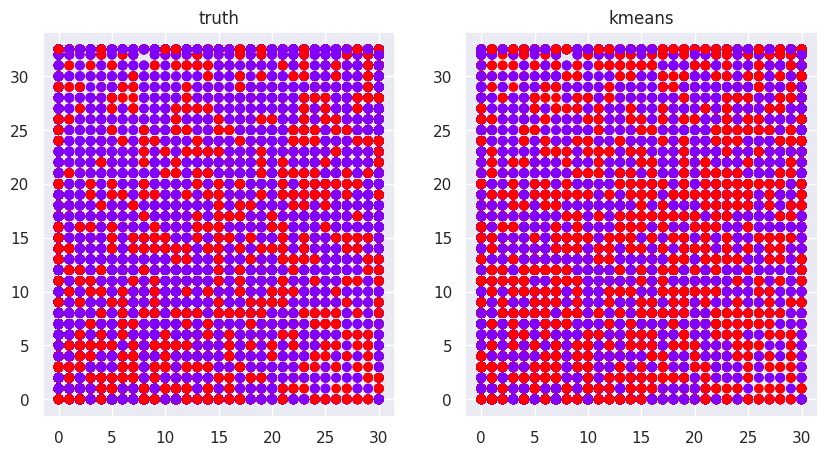

In [ ]:
fig = plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(feature1_1['Departure Delay in Minutes'], feature1_1['Arrival Delay in Minutes'], c=truth['satisfaction'], cmap='rainbow')
plt.title('truth')
plt.subplot(1, 2, 2)
plt.scatter(feature1_1['Departure Delay in Minutes'], feature1_1['Arrival Delay in Minutes'], c=y_kmeans_1_1, cmap='rainbow')
plt.title('kmeans')

plt.show()

### Đánh giá K-Means với cách tiền xử lý thứ hai

Các chỉ số đánh giá của K-Means trong trường hợp này được đối chiếu với hướng tiền xử lý trước đó để xác định cách biểu diễn biến `Class` nào hiệu quả hơn cho dữ liệu hiện tại.


In [ ]:
ARI(truth['satisfaction'],y_kmeans_1_1)

0.28214388204396973

In [ ]:
DBI(feature1_1, y_kmeans_1_1)

np.float64(1.5289535700885906)

### Áp dụng mô hình DBSCAN cho cách tiền xử lý thứ hai

Nhóm tiếp tục sử dụng DBSCAN trên dữ liệu đã mã hóa `Class` thành số, đồng thời thử nhiều bộ tham số để tìm ra cấu hình hợp lý nhất cho mô hình.


In [ ]:
from sklearn.cluster import DBSCAN

for eps in np.arange(0.5, 1.1, 0.1):
    for min_samples in range(2, 6):
        model1_1 = DBSCAN(eps=eps, min_samples=min_samples)
        y_DBSCAN_1_1 = model1_1.fit_predict(scaled_df1_1)

        # ARI
        ari = ARI(truth['satisfaction'], y_DBSCAN_1_1)

        # lọc noise
        mask_1 = y_DBSCAN_1_1 != -1

        if np.sum(mask_1) > 1 and len(set(y_DBSCAN_1_1[mask_1])) > 1:
            dbi = DBI(feature1_1[mask_1], y_DBSCAN_1_1[mask_1])
            print(f"eps={eps:.2f}, min_samples={min_samples}, ARI={ari:.4f}, DBI={dbi:.4f}")
        else:
            print(f"eps={eps:.2f}, min_samples={min_samples}, ARI={ari:.4f}, DBI=None")

eps=0.50, min_samples=2, ARI=0.0751, DBI=48.8128
eps=0.50, min_samples=3, ARI=0.0820, DBI=47.4433
eps=0.50, min_samples=4, ARI=0.0868, DBI=48.5876
eps=0.50, min_samples=5, ARI=0.0909, DBI=49.2008
eps=0.60, min_samples=2, ARI=0.0810, DBI=38.6896
eps=0.60, min_samples=3, ARI=0.0821, DBI=39.0209
eps=0.60, min_samples=4, ARI=0.0822, DBI=39.0110
eps=0.60, min_samples=5, ARI=0.0821, DBI=48.3600
eps=0.70, min_samples=2, ARI=0.0955, DBI=31.3044
eps=0.70, min_samples=3, ARI=0.0956, DBI=34.8761
eps=0.70, min_samples=4, ARI=0.0948, DBI=42.7253
eps=0.70, min_samples=5, ARI=0.0940, DBI=43.5357
eps=0.80, min_samples=2, ARI=0.1029, DBI=30.6119
eps=0.80, min_samples=3, ARI=0.1029, DBI=62.5396
eps=0.80, min_samples=4, ARI=0.1027, DBI=76.4751
eps=0.80, min_samples=5, ARI=0.1025, DBI=84.8942
eps=0.90, min_samples=2, ARI=0.1051, DBI=74.7862
eps=0.90, min_samples=3, ARI=0.1051, DBI=124.8887
eps=0.90, min_samples=4, ARI=0.1050, DBI=162.7113
eps=0.90, min_samples=5, ARI=0.1050, DBI=187.0657
eps=1.00, min_sam

### Áp dụng mô hình HDBSCAN cho cách tiền xử lý thứ hai

HDBSCAN được sử dụng như một phương án bổ sung để kiểm tra liệu việc thay đổi cách mã hóa `Class` có làm thay đổi đáng kể chất lượng phân cụm hay không.


In [ ]:
from sklearn.cluster import HDBSCAN

In [ ]:
hdbscan1=HDBSCAN(min_cluster_size=5)
y_hdbscan1=hdbscan1.fit_predict(scaled_df1_1)

### Đánh giá HDBSCAN với cách tiền xử lý thứ hai

Kết quả của HDBSCAN trong nhánh thực nghiệm này được tổng hợp và so sánh với các mô hình còn lại nhằm rút ra nhận xét chung về tác động của bước tiền xử lý.


In [ ]:
ARI(truth['satisfaction'],y_hdbscan1)

0.1050905720723954

In [ ]:
DBI(feature1_1, y_hdbscan1)

np.float64(149.32451624304016)

## 4.2. Thực nghiệm với bộ dữ liệu không xử lý outlier

Để đánh giá tác động của bước xử lý ngoại lệ, nhóm tiếp tục xây dựng các mô hình phân cụm trên bộ dữ liệu gốc, tức là chưa thực hiện cắt ngưỡng hoặc thay thế các giá trị bất thường. Kết quả thu được sẽ được so sánh với nhánh đã xử lý outlier để rút ra nhận xét về hiệu quả của bước tiền xử lý này.


In [ ]:
dataset2=dataset.copy()
dataset2

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
55610,0,1,53,0,Eco,163,3,5,3,1,...,4,4,3,1,5,4,3,0,0.0,neutral or dissatisfied
54894,0,0,21,1,Eco,1011,1,1,1,2,...,5,1,1,3,2,2,5,16,35.0,neutral or dissatisfied
55769,1,1,54,1,Business,1650,5,5,5,5,...,4,4,4,4,3,4,5,17,19.0,satisfied
63434,0,1,12,0,Eco,996,1,4,1,4,...,4,3,3,5,5,5,4,52,68.0,neutral or dissatisfied
23317,1,0,24,1,Eco,576,4,2,4,3,...,3,2,4,4,2,3,3,54,52.0,neutral or dissatisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35820,1,1,34,1,Business,1080,5,5,5,5,...,5,5,5,5,5,5,4,0,0.0,satisfied
16263,0,1,30,1,Business,1999,1,1,1,1,...,5,5,5,4,3,4,5,0,0.0,satisfied
29902,0,1,29,1,Eco,222,0,1,1,3,...,1,3,5,3,1,5,1,0,0.0,satisfied
89787,1,1,29,1,Business,3756,3,3,3,3,...,3,2,4,5,4,1,3,9,3.0,satisfied


In [ ]:
dataset2.isnull().sum()

,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0
Ease of Online booking,0
Gate location,0


In [ ]:
dataset2.dtypes

,0
Gender,int64
Customer Type,int64
Age,int64
Type of Travel,int64
Class,object
Flight Distance,int64
Inflight wifi service,int64
Departure/Arrival time convenient,int64
Ease of Online booking,int64
Gate location,int64


In [ ]:
feature2=dataset2.drop('satisfaction',axis=1)
feature2

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
55610,0,1,53,0,Eco,163,3,5,3,1,...,4,4,4,3,1,5,4,3,0,0.0
54894,0,0,21,1,Eco,1011,1,1,1,2,...,5,5,1,1,3,2,2,5,16,35.0
55769,1,1,54,1,Business,1650,5,5,5,5,...,4,4,4,4,4,3,4,5,17,19.0
63434,0,1,12,0,Eco,996,1,4,1,4,...,4,4,3,3,5,5,5,4,52,68.0
23317,1,0,24,1,Eco,576,4,2,4,3,...,3,3,2,4,4,2,3,3,54,52.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35820,1,1,34,1,Business,1080,5,5,5,5,...,5,5,5,5,5,5,5,4,0,0.0
16263,0,1,30,1,Business,1999,1,1,1,1,...,5,5,5,5,4,3,4,5,0,0.0
29902,0,1,29,1,Eco,222,0,1,1,3,...,1,1,3,5,3,1,5,1,0,0.0
89787,1,1,29,1,Business,3756,3,3,3,3,...,3,3,2,4,5,4,1,3,9,3.0


In [ ]:
target2=dataset2[['satisfaction']]
target2

,satisfaction
55610,neutral or dissatisfied
54894,neutral or dissatisfied
55769,satisfied
63434,neutral or dissatisfied
23317,neutral or dissatisfied
...,...
35820,satisfied
16263,satisfied
29902,satisfied
89787,satisfied


### Tiền xử lý hướng 1: One-Hot Encoding cho cột `Class`

Trong nhánh thực nghiệm này, dữ liệu không xử lý outlier nhưng vẫn được mã hóa `Class` bằng One-Hot Encoding. Việc giữ nguyên cách biểu diễn biến phân loại giúp nhóm tập trung đánh giá riêng tác động của bước xử lý ngoại lệ.


In [ ]:
from sklearn.preprocessing import OneHotEncoder
encoder2=OneHotEncoder()

In [ ]:
data_1hot_2=feature2[['Class']]
data_1hot_2

,Class
55610,Eco
54894,Eco
55769,Business
63434,Eco
23317,Eco
...,...
35820,Business
16263,Business
29902,Eco
89787,Business


In [ ]:
data_encoded2=encoder2.fit_transform(data_1hot_2)
data_encoded2

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 129880 stored elements and shape (129880, 3)>

In [ ]:
df_1hot_2 = pd.DataFrame.sparse.from_spmatrix(data_encoded2,
                                                 columns=encoder2.get_feature_names_out(),index=feature2.index)
df_1hot_2

,Class_Business,Class_Eco,Class_Eco Plus
55610,0,1.0,0
54894,0,1.0,0
55769,1.0,0,0
63434,0,1.0,0
23317,0,1.0,0
...,...,...,...
35820,1.0,0,0
16263,1.0,0,0
29902,0,1.0,0
89787,1.0,0,0


### Chuẩn hóa dữ liệu bằng `StandardScaler`

Trong nhánh không xử lý outlier, nhóm sử dụng `StandardScaler` thay cho `MinMaxScaler`. Kỹ thuật này biến đổi dữ liệu sao cho mỗi biến có:

- trung bình gần **0**
- độ lệch chuẩn gần **1**

Ý nghĩa của `StandardScaler`:
- giúp các biến có độ phân tán rất khác nhau trở nên cân bằng hơn,
- phù hợp khi muốn chuẩn hóa theo đơn vị độ lệch chuẩn thay vì ép dữ liệu vào một khoảng cố định,
- là một lựa chọn phổ biến cho các mô hình nhạy với khoảng cách.

Việc so sánh `StandardScaler` với `MinMaxScaler` cũng góp phần cho thấy bước chuẩn hóa ảnh hưởng thế nào đến kết quả phân cụm.

In [ ]:
from sklearn.preprocessing import StandardScaler
std_scaler=StandardScaler()

In [ ]:
data_scale2=feature2.drop('Class',axis=1)
data_scale2

,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
55610,0,1,53,0,163,3,5,3,1,4,...,4,4,4,3,1,5,4,3,0,0.0
54894,0,0,21,1,1011,1,1,1,2,5,...,5,5,1,1,3,2,2,5,16,35.0
55769,1,1,54,1,1650,5,5,5,5,4,...,4,4,4,4,4,3,4,5,17,19.0
63434,0,1,12,0,996,1,4,1,4,4,...,4,4,3,3,5,5,5,4,52,68.0
23317,1,0,24,1,576,4,2,4,3,3,...,3,3,2,4,4,2,3,3,54,52.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35820,1,1,34,1,1080,5,5,5,5,3,...,5,5,5,5,5,5,5,4,0,0.0
16263,0,1,30,1,1999,1,1,1,1,5,...,5,5,5,5,4,3,4,5,0,0.0
29902,0,1,29,1,222,0,1,1,3,1,...,1,1,3,5,3,1,5,1,0,0.0
89787,1,1,29,1,3756,3,3,3,3,3,...,3,3,2,4,5,4,1,3,9,3.0


In [ ]:
num_scale2=std_scaler.fit_transform(data_scale2)
num_scale2

array([[-0.98533997,  0.47342178,  0.89766337, ..., -0.21795753,
        -0.38648106, -0.39155247],
       [-0.98533997, -2.11228136, -1.21883648, ...,  1.30448651,
         0.03378656,  0.51949236],
       [ 1.01487815,  0.47342178,  0.963804  , ...,  1.30448651,
         0.06005328,  0.10301472],
       ...,
       [-0.98533997,  0.47342178, -0.68971152, ..., -1.74040158,
        -0.38648106, -0.39155247],
       [ 1.01487815,  0.47342178, -0.68971152, ..., -0.21795753,
        -0.15008053, -0.31346291],
       [-0.98533997,  0.47342178, -1.15269586, ...,  0.54326449,
        -0.36021434, -0.39155247]])

In [ ]:
df_scale2=pd.DataFrame(num_scale2,columns=std_scaler.get_feature_names_out(),index=feature2.index)
df_scale2

,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
55610,-0.985340,0.473422,0.897663,-1.493951,-1.029944,0.204090,1.272257,0.173445,-1.546267,0.597947,...,0.423441,0.481186,0.479357,-0.266574,-2.230567,1.337671,0.304086,-0.217958,-0.386481,-0.391552
54894,-0.985340,-2.112281,-1.218836,0.669366,-0.179775,-1.300421,-1.347712,-1.253359,-0.764109,1.349867,...,1.181428,1.230787,-1.851475,-1.786046,-0.535681,-1.031660,-1.395634,1.304487,0.033787,0.519492
55769,1.014878,0.473422,0.963804,0.669366,0.460859,1.708602,1.272257,1.600249,1.582364,0.597947,...,0.423441,0.481186,0.479357,0.493162,0.311762,-0.241883,0.304086,1.304487,0.060053,0.103015
63434,-0.985340,0.473422,-1.814102,-1.493951,-0.194813,-1.300421,0.617265,-1.253359,0.800206,0.597947,...,0.423441,0.481186,-0.297587,-0.266574,1.159206,1.337671,1.153946,0.543264,0.979389,1.378477
23317,1.014878,-2.112281,-1.020415,0.669366,-0.615888,0.956346,-0.692719,0.886847,0.018048,-0.153973,...,-0.334546,-0.268414,-1.074531,0.493162,0.311762,-1.031660,-0.545774,-0.217958,1.031922,0.962000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35820,1.014878,0.473422,-0.359008,0.669366,-0.110599,1.708602,1.272257,1.600249,1.582364,-0.153973,...,1.181428,1.230787,1.256300,1.252898,1.159206,1.337671,1.153946,0.543264,-0.386481,-0.391552
16263,-0.985340,0.473422,-0.623571,0.669366,0.810752,-1.300421,-1.347712,-1.253359,-1.546267,1.349867,...,1.181428,1.230787,1.256300,1.252898,0.311762,-0.241883,0.304086,1.304487,-0.386481,-0.391552
29902,-0.985340,0.473422,-0.689712,0.669366,-0.970793,-2.052677,-1.347712,-1.253359,0.018048,-1.657814,...,-1.850520,-1.767616,-0.297587,1.252898,-0.535681,-1.821437,1.153946,-1.740402,-0.386481,-0.391552
89787,1.014878,0.473422,-0.689712,0.669366,2.572246,0.204090,-0.037727,0.173445,0.018048,-0.153973,...,-0.334546,-0.268414,-1.074531,0.493162,1.159206,0.547894,-2.245494,-0.217958,-0.150081,-0.313463


In [ ]:
final_df2=pd.concat([df_scale2, df_1hot_2], axis=1, join='inner')
final_df2

,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Class_Business,Class_Eco,Class_Eco Plus
55610,-0.985340,0.473422,0.897663,-1.493951,-1.029944,0.204090,1.272257,0.173445,-1.546267,0.597947,...,-0.266574,-2.230567,1.337671,0.304086,-0.217958,-0.386481,-0.391552,0,1.0,0
54894,-0.985340,-2.112281,-1.218836,0.669366,-0.179775,-1.300421,-1.347712,-1.253359,-0.764109,1.349867,...,-1.786046,-0.535681,-1.031660,-1.395634,1.304487,0.033787,0.519492,0,1.0,0
55769,1.014878,0.473422,0.963804,0.669366,0.460859,1.708602,1.272257,1.600249,1.582364,0.597947,...,0.493162,0.311762,-0.241883,0.304086,1.304487,0.060053,0.103015,1.0,0,0
63434,-0.985340,0.473422,-1.814102,-1.493951,-0.194813,-1.300421,0.617265,-1.253359,0.800206,0.597947,...,-0.266574,1.159206,1.337671,1.153946,0.543264,0.979389,1.378477,0,1.0,0
23317,1.014878,-2.112281,-1.020415,0.669366,-0.615888,0.956346,-0.692719,0.886847,0.018048,-0.153973,...,0.493162,0.311762,-1.031660,-0.545774,-0.217958,1.031922,0.962000,0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35820,1.014878,0.473422,-0.359008,0.669366,-0.110599,1.708602,1.272257,1.600249,1.582364,-0.153973,...,1.252898,1.159206,1.337671,1.153946,0.543264,-0.386481,-0.391552,1.0,0,0
16263,-0.985340,0.473422,-0.623571,0.669366,0.810752,-1.300421,-1.347712,-1.253359,-1.546267,1.349867,...,1.252898,0.311762,-0.241883,0.304086,1.304487,-0.386481,-0.391552,1.0,0,0
29902,-0.985340,0.473422,-0.689712,0.669366,-0.970793,-2.052677,-1.347712,-1.253359,0.018048,-1.657814,...,1.252898,-0.535681,-1.821437,1.153946,-1.740402,-0.386481,-0.391552,0,1.0,0
89787,1.014878,0.473422,-0.689712,0.669366,2.572246,0.204090,-0.037727,0.173445,0.018048,-0.153973,...,0.493162,1.159206,0.547894,-2.245494,-0.217958,-0.150081,-0.313463,1.0,0,0


In [ ]:
truth2=target2
truth2['satisfaction']=truth2['satisfaction'].replace('neutral or dissatisfied',0)
truth2['satisfaction']=truth2['satisfaction'].replace('satisfied',1)
truth2

/tmp/ipykernel_14155/3325232629.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  truth2['satisfaction']=truth2['satisfaction'].replace('neutral or dissatisfied',0)
/tmp/ipykernel_14155/3325232629.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  truth2['satisfaction']=truth2['satisfaction'].replace('satisfied',1)
/tmp/ipykernel_14155/3325232629.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i

,satisfaction
55610,0
54894,0
55769,1
63434,0
23317,0
...,...
35820,1
16263,1
29902,1
89787,1


### Áp dụng mô hình K-Means

Sau khi hoàn tất bước tiền xử lý, nhóm huấn luyện mô hình K-Means trên bộ dữ liệu chưa xử lý outlier để quan sát sự khác biệt về chất lượng phân cụm so với nhánh còn lại.


In [ ]:
kmeans_2=KMeans(n_clusters=2)
y_kmeans2 = kmeans_2.fit_predict(final_df2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


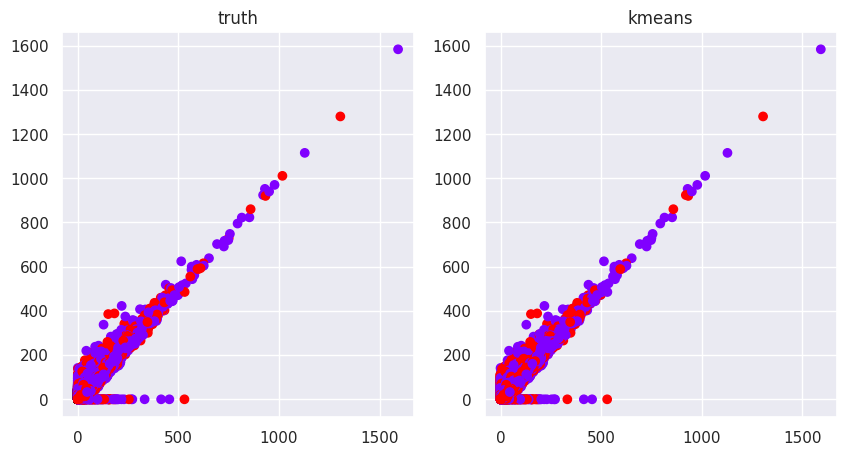

In [ ]:
fig = plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(feature2['Departure Delay in Minutes'], feature2['Arrival Delay in Minutes'], c=truth2['satisfaction'], cmap='rainbow')
plt.title('truth')
plt.subplot(1, 2, 2)
plt.scatter(feature2['Departure Delay in Minutes'], feature2['Arrival Delay in Minutes'], c=y_kmeans2, cmap='rainbow')
plt.title('kmeans')

plt.show()

### Đánh giá mô hình K-Means

Ở nhánh này, K-Means tiếp tục được đánh giá bằng ARI và DBI. Việc giữ nguyên thước đo đánh giá giữa các nhánh thực nghiệm giúp nhóm so sánh công bằng tác động của:

- có xử lý outlier hay không,
- dùng `MinMaxScaler` hay `StandardScaler`,
- dùng One-Hot Encoding hay mã hóa số cho `Class`.

In [ ]:
ARI(truth2['satisfaction'],y_kmeans2)

0.25289547212930263

In [ ]:
DBI(final_df2,y_kmeans2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


np.float64(2.4963402013650056)

In [ ]:
kmeans_after1=KMeans(n_clusters=2, algorithm='elkan')
y_kmeans_after1 = kmeans_after1.fit_predict(final_df2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [ ]:
ARI(truth2['satisfaction'],y_kmeans_after1)

0.2517155813823005

In [ ]:
DBI(final_df2,y_kmeans_after1)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


np.float64(2.496242217330965)

### Áp dụng mô hình DBSCAN

DBSCAN tiếp tục được sử dụng trên bộ dữ liệu chưa xử lý outlier nhằm kiểm tra mức độ nhạy của thuật toán mật độ đối với các điểm bất thường trong dữ liệu.


In [ ]:
for eps in np.arange(0.5, 1.1, 0.1):
    for min_samples in range(2, 6):
        model2 = DBSCAN(eps=eps, min_samples=min_samples)
        y_DBSCAN2 = model2.fit_predict(final_df2)

        # ARI
        ari2 = ARI(truth2['satisfaction'], y_DBSCAN2)

        # lọc noise
        mask_2 = y_DBSCAN2 != -1

        if np.sum(mask_2) > 1 and len(set(y_DBSCAN2[mask_2])) > 1:
            dbi2 = DBI(final_df2[mask_2], y_DBSCAN2[mask_2])
            print(f"eps={eps:.2f}, min_samples={min_samples}, ARI={ari2:.4f}, DBI={dbi2:.4f}")
        else:
            print(f"eps={eps:.2f}, min_samples={min_samples}, ARI={ari2:.4f}, DBI=None")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


eps=0.50, min_samples=2, ARI=0.0189, DBI=0.3693


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


eps=0.50, min_samples=3, ARI=0.0051, DBI=0.4085


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


eps=1.10, min_samples=3, ARI=0.1106, DBI=0.9633


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


eps=1.10, min_samples=4, ARI=0.1113, DBI=1.0598
eps=1.10, min_samples=5, ARI=0.1074, DBI=1.2196


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


### Áp dụng mô hình HDBSCAN

Nhóm sử dụng HDBSCAN như một phương án bổ sung để so sánh với DBSCAN và K-Means trong điều kiện không xử lý outlier.


In [ ]:
hdbscan2=HDBSCAN(min_cluster_size=5)
y_hdbscan2=hdbscan2.fit_predict(final_df2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [ ]:
ARI(truth2['satisfaction'],y_hdbscan2)

-0.0005185611935302227

In [ ]:
DBI(final_df2,y_hdbscan2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


np.float64(1.616826358434482)

### Tiền xử lý hướng 2: Chuyển đổi dữ liệu cột `Class` thành số

Trong hướng xử lý thứ hai của nhánh này, `Class` được biểu diễn dưới dạng số thay vì One-Hot Encoding. Cách làm này cho phép nhóm kiểm tra thêm ảnh hưởng của phương pháp mã hóa trong điều kiện không xử lý ngoại lệ.


In [ ]:
feature2_1=feature2.copy()
feature2_1

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
55610,0,1,53,0,Eco,163,3,5,3,1,...,4,4,4,3,1,5,4,3,0,0.0
54894,0,0,21,1,Eco,1011,1,1,1,2,...,5,5,1,1,3,2,2,5,16,35.0
55769,1,1,54,1,Business,1650,5,5,5,5,...,4,4,4,4,4,3,4,5,17,19.0
63434,0,1,12,0,Eco,996,1,4,1,4,...,4,4,3,3,5,5,5,4,52,68.0
23317,1,0,24,1,Eco,576,4,2,4,3,...,3,3,2,4,4,2,3,3,54,52.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35820,1,1,34,1,Business,1080,5,5,5,5,...,5,5,5,5,5,5,5,4,0,0.0
16263,0,1,30,1,Business,1999,1,1,1,1,...,5,5,5,5,4,3,4,5,0,0.0
29902,0,1,29,1,Eco,222,0,1,1,3,...,1,1,3,5,3,1,5,1,0,0.0
89787,1,1,29,1,Business,3756,3,3,3,3,...,3,3,2,4,5,4,1,3,9,3.0


In [ ]:
feature2_1['Class']=feature2_1['Class'].replace('Eco',0)
feature2_1['Class']=feature2_1['Class'].replace('Eco Plus',1)
feature2_1['Class']=feature2_1['Class'].replace('Business',2)
feature2_1

/tmp/ipykernel_14155/1009070657.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  feature2_1['Class']=feature2_1['Class'].replace('Business',2)


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
55610,0,1,53,0,0,163,3,5,3,1,...,4,4,4,3,1,5,4,3,0,0.0
54894,0,0,21,1,0,1011,1,1,1,2,...,5,5,1,1,3,2,2,5,16,35.0
55769,1,1,54,1,2,1650,5,5,5,5,...,4,4,4,4,4,3,4,5,17,19.0
63434,0,1,12,0,0,996,1,4,1,4,...,4,4,3,3,5,5,5,4,52,68.0
23317,1,0,24,1,0,576,4,2,4,3,...,3,3,2,4,4,2,3,3,54,52.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35820,1,1,34,1,2,1080,5,5,5,5,...,5,5,5,5,5,5,5,4,0,0.0
16263,0,1,30,1,2,1999,1,1,1,1,...,5,5,5,5,4,3,4,5,0,0.0
29902,0,1,29,1,0,222,0,1,1,3,...,1,1,3,5,3,1,5,1,0,0.0
89787,1,1,29,1,2,3756,3,3,3,3,...,3,3,2,4,5,4,1,3,9,3.0


In [ ]:
std_scaler2=StandardScaler()

In [ ]:
number_scale=std_scaler2.fit_transform(feature2_1)
number_scale

array([[-0.98533997,  0.47342178,  0.89766337, ..., -0.21795753,
        -0.38648106, -0.39155247],
       [-0.98533997, -2.11228136, -1.21883648, ...,  1.30448651,
         0.03378656,  0.51949236],
       [ 1.01487815,  0.47342178,  0.963804  , ...,  1.30448651,
         0.06005328,  0.10301472],
       ...,
       [-0.98533997,  0.47342178, -0.68971152, ..., -1.74040158,
        -0.38648106, -0.39155247],
       [ 1.01487815,  0.47342178, -0.68971152, ..., -0.21795753,
        -0.15008053, -0.31346291],
       [-0.98533997,  0.47342178, -1.15269586, ...,  0.54326449,
        -0.36021434, -0.39155247]])

In [ ]:
df_end=pd.DataFrame(number_scale,columns=std_scaler2.get_feature_names_out(),index=feature2_1.index)
df_end

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
55610,-0.985340,0.473422,0.897663,-1.493951,-1.069619,-1.029944,0.204090,1.272257,0.173445,-1.546267,...,0.423441,0.481186,0.479357,-0.266574,-2.230567,1.337671,0.304086,-0.217958,-0.386481,-0.391552
54894,-0.985340,-2.112281,-1.218836,0.669366,-1.069619,-0.179775,-1.300421,-1.347712,-1.253359,-0.764109,...,1.181428,1.230787,-1.851475,-1.786046,-0.535681,-1.031660,-1.395634,1.304487,0.033787,0.519492
55769,1.014878,0.473422,0.963804,0.669366,1.008016,0.460859,1.708602,1.272257,1.600249,1.582364,...,0.423441,0.481186,0.479357,0.493162,0.311762,-0.241883,0.304086,1.304487,0.060053,0.103015
63434,-0.985340,0.473422,-1.814102,-1.493951,-1.069619,-0.194813,-1.300421,0.617265,-1.253359,0.800206,...,0.423441,0.481186,-0.297587,-0.266574,1.159206,1.337671,1.153946,0.543264,0.979389,1.378477
23317,1.014878,-2.112281,-1.020415,0.669366,-1.069619,-0.615888,0.956346,-0.692719,0.886847,0.018048,...,-0.334546,-0.268414,-1.074531,0.493162,0.311762,-1.031660,-0.545774,-0.217958,1.031922,0.962000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35820,1.014878,0.473422,-0.359008,0.669366,1.008016,-0.110599,1.708602,1.272257,1.600249,1.582364,...,1.181428,1.230787,1.256300,1.252898,1.159206,1.337671,1.153946,0.543264,-0.386481,-0.391552
16263,-0.985340,0.473422,-0.623571,0.669366,1.008016,0.810752,-1.300421,-1.347712,-1.253359,-1.546267,...,1.181428,1.230787,1.256300,1.252898,0.311762,-0.241883,0.304086,1.304487,-0.386481,-0.391552
29902,-0.985340,0.473422,-0.689712,0.669366,-1.069619,-0.970793,-2.052677,-1.347712,-1.253359,0.018048,...,-1.850520,-1.767616,-0.297587,1.252898,-0.535681,-1.821437,1.153946,-1.740402,-0.386481,-0.391552
89787,1.014878,0.473422,-0.689712,0.669366,1.008016,2.572246,0.204090,-0.037727,0.173445,0.018048,...,-0.334546,-0.268414,-1.074531,0.493162,1.159206,0.547894,-2.245494,-0.217958,-0.150081,-0.313463


### Mô hình K-Means

K-Means được áp dụng trên bộ dữ liệu với cách mã hóa `Class` thành số để tiếp tục so sánh giữa các chiến lược tiền xử lý khác nhau.


In [ ]:
kmeans_2_1=KMeans(n_clusters=2)
y_kmeans2_1 = kmeans_2_1.fit_predict(df_end)

In [ ]:
ARI(truth2['satisfaction'],y_kmeans2_1)

0.28331795106429675

In [ ]:
DBI(df_end,y_kmeans2_1)

np.float64(2.494776637622897)

In [ ]:
kmeans_after_2=KMeans(n_clusters=2, algorithm='elkan')
y_kmeans_after2 = kmeans_after_2.fit_predict(df_end)

In [ ]:
ARI(truth2['satisfaction'],y_kmeans_after2)

0.27934231205864307

In [ ]:
DBI(df_end,y_kmeans_after2)

np.float64(2.4951475495434225)

### Mô hình DBSCAN

DBSCAN được áp dụng trong cùng điều kiện tiền xử lý để đánh giá khả năng nhận diện cụm và nhiễu khi dữ liệu vẫn còn các giá trị ngoại lệ.


In [ ]:
from sklearn.cluster import DBSCAN

for eps in np.arange(0.5, 1.1, 0.1):
    for min_samples in range(2, 6):
        model2_1 = DBSCAN(eps=eps, min_samples=min_samples)
        y_DBSCAN_2_1 = model2_1.fit_predict(df_end)

        # ARI
        ari2_1 = ARI(truth2['satisfaction'], y_DBSCAN_2_1)

        # lọc noise
        mask2_1 = y_DBSCAN_2_1 != -1

        if np.sum(mask2_1) > 1 and len(set(y_DBSCAN_2_1[mask2_1])) > 1:
            dbi2_1 = DBI(feature1_1[mask2_1], y_DBSCAN_2_1[mask2_1])
            print(f"eps={eps:.2f}, min_samples={min_samples}, ARI={ari2_1:.4f}, DBI={dbi2_1:.4f}")
        else:
            print(f"eps={eps:.2f}, min_samples={min_samples}, ARI={ari2_1:.4f}, DBI=None")

eps=0.50, min_samples=2, ARI=0.0189, DBI=35.6600
eps=0.50, min_samples=3, ARI=0.0051, DBI=32.4199
eps=0.50, min_samples=4, ARI=0.0009, DBI=15.9859
eps=0.50, min_samples=5, ARI=0.0001, DBI=3.8038
eps=0.60, min_samples=2, ARI=0.0265, DBI=45.1659
eps=0.60, min_samples=3, ARI=0.0090, DBI=45.5705
eps=0.60, min_samples=4, ARI=0.0023, DBI=30.5181
eps=0.60, min_samples=5, ARI=0.0004, DBI=7.2562
eps=0.70, min_samples=2, ARI=0.0342, DBI=53.3890
eps=0.70, min_samples=3, ARI=0.0142, DBI=60.1817
eps=0.70, min_samples=4, ARI=0.0045, DBI=42.3016
eps=0.70, min_samples=5, ARI=0.0010, DBI=22.4805
eps=0.80, min_samples=2, ARI=0.0563, DBI=53.6598
eps=0.80, min_samples=3, ARI=0.0413, DBI=67.1931
eps=0.80, min_samples=4, ARI=0.0238, DBI=62.7222
eps=0.80, min_samples=5, ARI=0.0117, DBI=55.2181
eps=0.90, min_samples=2, ARI=0.0825, DBI=40.7116
eps=0.90, min_samples=3, ARI=0.0785, DBI=48.7145
eps=0.90, min_samples=4, ARI=0.0689, DBI=49.6288
eps=0.90, min_samples=5, ARI=0.0574, DBI=49.4507
eps=1.00, min_samples=

### Mô hình HDBSCAN

HDBSCAN là mô hình cuối cùng được sử dụng trong nhánh thực nghiệm này nhằm hoàn thiện quá trình so sánh giữa các thuật toán và các cách biểu diễn dữ liệu khác nhau.


In [ ]:
from sklearn.cluster import HDBSCAN
hdbscan2_1=HDBSCAN(min_cluster_size=5)
y_hdbscan2_1=hdbscan2_1.fit_predict(df_end)

In [ ]:
ARI(truth2['satisfaction'],y_hdbscan2_1)

-0.0004310015258956131

In [ ]:
DBI(df_end,y_hdbscan2_1)

np.float64(1.6219649286311943)

## 5. Tổng hợp và đánh giá các mô hình

Sau khi hoàn thành các thực nghiệm, nhóm tiến hành tổng hợp kết quả để so sánh giữa các mô hình, cách tiền xử lý và tác động của việc xử lý outlier. Trong đồ án này, hai chỉ số được sử dụng để đánh giá là:

- **ARI (Adjusted Rand Index):** đo mức độ khớp giữa nhãn cụm do mô hình tạo ra và nhãn thật `satisfaction`. Giá trị càng gần **1** thì cụm tạo ra càng gần với hai nhóm hài lòng / không hài lòng trong thực tế.
- **DBI (Davies–Bouldin Index):** đo độ chặt trong cụm và độ tách giữa các cụm. Giá trị càng **nhỏ** thì chất lượng phân cụm càng tốt.

Nói ngắn gọn, **ARI** trả lời câu hỏi *“cụm có khớp với nhãn thật không?”*, còn **DBI** trả lời câu hỏi *“cụm có chặt và tách nhau tốt không?”*. Vì vậy, khi đánh giá kết quả, nhóm cần xem đồng thời cả hai chỉ số.

### 5.1. Bảng tổng hợp kết quả chính

| Nhánh thực nghiệm | Mô hình | ARI | DBI | Nhận xét ngắn |
|---|---|---:|---:|---|
| Có xử lý outlier + One-Hot `Class` + MinMaxScaler | K-Means | 0.2664 | 1.8644 | Kết quả tốt và ổn định |
| Có xử lý outlier + One-Hot `Class` + MinMaxScaler | K-Means (Elkan) | 0.2665 | 1.8644 | Gần như không khác K-Means thường |
| Có xử lý outlier + One-Hot `Class` + MinMaxScaler | DBSCAN (tốt nhất theo ARI) | **0.2139** | 2.6454 | ARI khá hơn các nhánh DBSCAN còn lại |
| Có xử lý outlier + One-Hot `Class` + MinMaxScaler | DBSCAN (tốt nhất theo DBI) | 0.0751 | **1.1057** | Cụm khá chặt nhưng khớp nhãn thấp |
| Có xử lý outlier + One-Hot `Class` + MinMaxScaler | HDBSCAN | 0.0888 | 2.1651 | Kém hơn K-Means và DBSCAN |
| Có xử lý outlier + Mã hóa số `Class` + MinMaxScaler | K-Means | **0.2821** | **1.5290** | Tốt nhất trong nhóm có xử lý outlier |
| Có xử lý outlier + Mã hóa số `Class` + MinMaxScaler | DBSCAN (tốt nhất theo ARI) | 0.1055 | 113.0069 | ARI thấp, DBI rất cao |
| Có xử lý outlier + Mã hóa số `Class` + MinMaxScaler | HDBSCAN | 0.1051 | 149.3245 | Chất lượng cụm rất kém |
| Không xử lý outlier + One-Hot `Class` + StandardScaler | K-Means | 0.2529 | 2.4963 | Kém hơn nhánh có xử lý outlier |
| Không xử lý outlier + One-Hot `Class` + StandardScaler | K-Means (Elkan) | 0.2517 | 2.4962 | Không cải thiện đáng kể |
| Không xử lý outlier + One-Hot `Class` + StandardScaler | DBSCAN (tốt nhất theo ARI) | 0.1113 | 1.0598 | ARI thấp nhưng DBI khá tốt |
| Không xử lý outlier + One-Hot `Class` + StandardScaler | HDBSCAN | -0.0005 | 1.6168 | Gần như không khớp nhãn thật |
| Không xử lý outlier + Mã hóa số `Class` + StandardScaler | K-Means | **0.2833** | 2.4948 | ARI cao nhất toàn bộ thực nghiệm |
| Không xử lý outlier + Mã hóa số `Class` + StandardScaler | K-Means (Elkan) | 0.2793 | 2.4951 | Rất gần K-Means thường |
| Không xử lý outlier + Mã hóa số `Class` + StandardScaler | DBSCAN (tốt nhất theo ARI) | 0.1113 | 67.9145 | ARI ngang One-Hot nhưng DBI rất xấu |
| Không xử lý outlier + Mã hóa số `Class` + StandardScaler | HDBSCAN | -0.0004 | 1.6220 | Hầu như không học được cấu trúc phù hợp |

### 5.2. Thuật toán nào cho kết quả tốt nhất?

Nếu lấy **ARI** làm tiêu chí chính, thì **K-Means** là mô hình cho kết quả tốt nhất và ổn định nhất trong toàn bộ các nhánh thực nghiệm. Hai kết quả cao nhất đều thuộc về K-Means:

- **0.2833** ở nhánh **không xử lý outlier + mã hóa số `Class`**
- **0.2821** ở nhánh **có xử lý outlier + mã hóa số `Class`**

Trong khi đó:

- DBSCAN chỉ đạt tốt nhất khoảng **0.2139** ở nhánh **có xử lý outlier + One-Hot**
- các nhánh DBSCAN còn lại chỉ quanh **0.105 – 0.111**
- HDBSCAN chỉ đạt khoảng **0.0888 – 0.1051**, thậm chí có nhánh gần **0**

Điều này cho thấy với bộ dữ liệu hiện tại, cấu trúc dữ liệu phù hợp hơn với cách chia cụm theo **tâm cụm** của K-Means so với các mô hình dựa trên **mật độ** như DBSCAN và HDBSCAN.

Nếu chỉ nhìn vào **DBI**, một số cấu hình DBSCAN cho kết quả khá thấp, ví dụ:

- **0.1846** ở nhánh **không xử lý outlier + One-Hot** với `eps=0.5`, `min_samples=5`
- **1.1057** ở nhánh **có xử lý outlier + One-Hot** với `eps=0.5`, `min_samples=2`

Tuy nhiên, ở các cấu hình này, **ARI lại rất thấp**. Điều đó có nghĩa là cụm tạo ra có thể “đẹp” về mặt hình học, nhưng **không trùng với nhãn `satisfaction`** mà nhóm quan tâm. Vì vậy, nếu mục tiêu là tạo cụm gần với nhãn thật, **K-Means vẫn là lựa chọn phù hợp nhất**.

### 5.3. Cách biểu diễn biến `Class` nào phù hợp hơn?

Kết quả cho thấy **mã hóa số cho biến `Class` phù hợp hơn với K-Means**, trong khi **One-Hot Encoding phù hợp hơn với DBSCAN**.

#### Đối với K-Means

Ở cả hai điều kiện có và không xử lý outlier, K-Means đều cho kết quả tốt hơn khi `Class` được mã hóa thành số:

- **Có xử lý outlier**
  - One-Hot: ARI = **0.2664**, DBI = **1.8644**
  - Mã hóa số: ARI = **0.2821**, DBI = **1.5290**

- **Không xử lý outlier**
  - One-Hot: ARI = **0.2529**, DBI = **2.4963**
  - Mã hóa số: ARI = **0.2833**, DBI = **2.4948**

Điều này cho thấy khi sử dụng K-Means, việc biểu diễn `Class` bằng giá trị số giúp mô hình phân tách dữ liệu tốt hơn.

#### Đối với DBSCAN

Sau khi cập nhật lại notebook, có thể thấy DBSCAN không còn cho kết quả tốt ở nhánh **mã hóa số `Class`** như trước. Cụ thể:

- **Có xử lý outlier + mã hóa số:** ARI tốt nhất chỉ khoảng **0.1055**
- **Không xử lý outlier + mã hóa số:** ARI tốt nhất khoảng **0.1113**, nhưng DBI lên tới **67.9145**

Trong khi đó, với **One-Hot Encoding**:

- **Có xử lý outlier + One-Hot:** DBSCAN đạt ARI tốt nhất **0.2139**
- **Không xử lý outlier + One-Hot:** DBSCAN đạt ARI tốt nhất **0.1113** và DBI chỉ **1.0598**

Như vậy, có thể rút ra rằng:

> **Mã hóa số cho `Class` phù hợp hơn với K-Means, còn One-Hot Encoding phù hợp hơn với DBSCAN.**

### 5.4. Việc xử lý outlier có thực sự cải thiện mô hình hay không?

Kết quả cho thấy **xử lý outlier giúp cải thiện rõ rệt chất lượng cụm của K-Means**, đặc biệt nếu nhìn theo DBI.

#### Với One-Hot Encoding

- **Có xử lý outlier + K-Means:** ARI = **0.2664**, DBI = **1.8644**
- **Không xử lý outlier + K-Means:** ARI = **0.2529**, DBI = **2.4963**

Sau khi xử lý outlier:

- ARI tăng khoảng **0.0135**
- DBI giảm khoảng **0.6319**

Điều này cho thấy xử lý outlier giúp dữ liệu ổn định hơn và cụm tạo ra gọn hơn.

#### Với mã hóa số `Class`

- **Có xử lý outlier + K-Means:** ARI = **0.2821**, DBI = **1.5290**
- **Không xử lý outlier + K-Means:** ARI = **0.2833**, DBI = **2.4948**

Ở đây:

- ARI gần như không thay đổi
- nhưng DBI giảm mạnh, khoảng **0.9658**

Điều đó cho thấy xử lý outlier không nhất thiết làm tăng mạnh độ khớp với nhãn thật, nhưng **cải thiện rất rõ chất lượng hình học của cụm**.

Vì vậy, nhóm có thể kết luận:

> **Xử lý outlier là bước có ích, đặc biệt đối với các mô hình nhạy với khoảng cách như K-Means.**

### 5.5. Nhận xét về DBSCAN sau khi cập nhật kết quả

Sau khi chạy lại notebook, kết quả DBSCAN thay đổi đáng kể so với phần tổng hợp trước đó. Điểm nổi bật là:

- nhánh **mã hóa số `Class`** không còn cho kết quả DBSCAN tốt như trước
- hai nhánh **không xử lý outlier** đã có kết quả DBSCAN đầy đủ để so sánh
- DBSCAN cho thấy chất lượng rất phụ thuộc vào cách biểu diễn dữ liệu và tham số `eps`, `min_samples`

Một điểm đáng chú ý là DBSCAN thường xuất hiện tình huống:

- **DBI thấp nhưng ARI thấp**
- hoặc **ARI tăng nhẹ nhưng DBI rất cao**

Điều này cho thấy DBSCAN có thể phát hiện được một số cấu trúc hình học trong dữ liệu, nhưng các cấu trúc đó **không nhất thiết trùng với nhãn hài lòng / không hài lòng**.

### 5.6. Nhận xét về HDBSCAN

HDBSCAN cho kết quả không tốt trong hầu hết các nhánh thực nghiệm:

- **Có xử lý outlier + One-Hot:** ARI = **0.0888**
- **Có xử lý outlier + mã hóa số:** ARI = **0.1051**, DBI = **149.3245**
- **Không xử lý outlier + One-Hot:** ARI gần **0**
- **Không xử lý outlier + mã hóa số:** ARI gần **0**

Kết quả này cho thấy dữ liệu hiện tại không thực sự phù hợp với giả định phân cụm theo mật độ thay đổi của HDBSCAN, hoặc thuật toán này chưa khai thác được cấu trúc cần thiết để bám sát nhãn `satisfaction`.

### 5.7. Nhận xét về K-Means Elkan

Nhóm cũng thử thay đổi thuật toán nội bộ của K-Means sang **Elkan**, tuy nhiên kết quả gần như không khác biệt đáng kể:

- **0.2664 → 0.2665** ở nhánh có xử lý outlier + One-Hot
- **0.2529 → 0.2517** ở nhánh không xử lý outlier + One-Hot
- **0.2833 → 0.2793** ở nhánh không xử lý outlier + mã hóa số

Như vậy, việc đổi sang Elkan **không tạo ra cải thiện rõ rệt về chất lượng phân cụm**, mà chủ yếu chỉ là một lựa chọn khác về mặt tối ưu tính toán.

### 5.8. Kết luận tổng hợp

Từ các kết quả đã cập nhật, nhóm có thể rút ra các kết luận chính như sau:

1. **K-Means vẫn là mô hình phù hợp nhất** nếu mục tiêu là tạo ra các cụm gần với nhãn `satisfaction`.
2. **Mã hóa số cho biến `Class` phù hợp hơn với K-Means** và cho ARI cao nhất toàn bộ thực nghiệm.
3. **One-Hot Encoding phù hợp hơn với DBSCAN**, đặc biệt sau khi chạy lại các nhánh DBSCAN mới.
4. **Xử lý outlier giúp cải thiện rõ chất lượng cụm**, nhất là đối với K-Means.
5. **HDBSCAN không cho kết quả tốt** trên bộ dữ liệu này.

Nhìn chung, nếu chọn một cấu hình đại diện cho kết quả tốt nhất của đồ án, nhóm có thể ưu tiên **K-Means kết hợp với mã hóa số cho `Class`**, đồng thời **xử lý outlier** để làm cho cấu trúc cụm ổn định hơn.